# **Computational Drug Discovery Pipeline for PfDHODH Inhibitors**
## Complete Notebook: Phases 1-9 (Ready for Deployment)

**Author**: Festus Ogungbemiro [Presented as a tutorial project at CADD 2.0]  
**Institution**: CBIOS - Universidade Lusofona, Lisbon, Portugal
**Date**: April, 2026

**STATUS**: ✅ COMPLETE - All phases integrated and ready to run

---

## 📋 Instructions

This notebook contains **ALL phases (1-9)** in a single, ready-to-run file.

### ✨ What to Do:

1. **Run all cells** in order from top to bottom
2. **Wait** for completion (5-10 minutes)
3. **Check** for `PfDHODH_deployment_models` folder
4. **Copy** folder to Streamlit app directory
5. **Run** Streamlit app

---


# Computational Drug Discovery Pipeline for PfDHODH Inhibitors

## A Quantitative Structure-Activity Relationship (QSAR) Study

**Author**: Festus Ogungbemiro  
**Institution**: CBIOS - Universidade Lusofona, BioNatural and Computational Chemistry Research Group  
**Date**: April, 2026

---

## Abstract

This research presents a comprehensive computational drug discovery pipeline targeting *Plasmodium falciparum* Dihydroorotate dehydrogenase (PfDHODH) to support the development of novel antimalarial agents. Leveraging the ChEMBL database, the study curated 369 high-quality bioactive compounds and implemented an automated 9-phase workflow covering data acquisition, feature engineering, and predictive modeling. The research achieved outstanding results with a Support Vector Regression model that attained an R² value exceeding 0.70, and a Random Forest Classification Model, effectively modeling a wide bioactivity range from pIC50 3.06 to 8.22. Additionally, the study successfully integrated 2048-bit Morgan fingerprints and 17 physicochemical descriptors to classify compounds into active, intermediate, and inactive categories. A significant achievement of this work is the end-to-end automation of the pipeline, which transitions from raw chemical data to a validated predictive model. Finally, the research culminated in the deployment of a functional Streamlit web application, providing an accessible interface for real-time bioactivity prediction and drug-likeness screening.

### Keywords
PfDHODH, Plasmodium falciparum, QSAR Modeling, Machine Learning, Cheminformatics, Streamlit Deployment, Drug Discovery, Molecular Descriptors, ChEMBL

---

## 1. Introduction

### 1.1 Biological Background

**PfDHODH** is a mitochondrial enzyme essential for *de novo* pyrimidine biosynthesis in *Plasmodium falciparum*, the primary cause of severe malaria. Unlike human cells, the parasite lacks a pyrimidine salvage pathway, making it entirely dependent on this enzyme for DNA/RNA production and cellular survival. Consequently, inhibiting PfDHODH provides a validated strategy for selective toxicity, allowing for the design of potent antimalarial leads with minimal side effects.

### 1.2 Computational Approach

This study employs **Quantitative Structure-Activity Relationship (QSAR)** modeling to establish mathematical relationships between molecular structure and biological activity. By leveraging machine learning algorithms and molecular descriptors, we aim to:

1. Predict IC50 values for virtual screening
2. Classify compounds as active or inactive
3. Identify key molecular features driving bioactivity
4. Guide medicinal chemistry optimization

### 1.3 Methodology Overview

Our pipeline consists of eight integrated phases:

- **Phase 1**: Data acquisition from ChEMBL database
- **Phase 2**: Data preprocessing and bioactivity classification
- **Phase 3**: pIC50 transformation for modeling
- **Phase 4**: Molecular descriptor calculation (physicochemical + fingerprints)
- **Phase 5**: Exploratory data analysis and feature selection
- **Phase 6**: Advanced regression modeling with hyperparameter optimization
- **Phase 7**: Binary classification for hit identification
- **Phase 8**: Model interpretation and validation

---


## 2. Materials and Methods

### 2.1 Software and Libraries

All analyses were performed using Python 3.11 with the following libraries:

- **RDKit** (2023.09): Cheminformatics and molecular descriptor calculation
- **Pandas** (2.1.0): Data manipulation and analysis
- **NumPy** (1.25.0): Numerical computations
- **Scikit-learn** (1.3.0): Machine learning algorithms and evaluation
- **Matplotlib** (3.7.0) & **Seaborn** (0.12.0): Data visualization
- **Requests** (2.31.0): API communication

### 2.2 Data Source

Bioactivity data was retrieved from the **ChEMBL database** (version 33), a manually curated repository of bioactive molecules with drug-like properties. We queried IC50 values for PfDHODH  (ChEMBL ID: CHEMBLCHEMBL3486) from  *Plasmodium falciparum* assays.

### 2.3 Bioactivity Classification Criteria

Compounds were classified based on IC50 values according to established medicinal chemistry guidelines:

- **Active**: IC50 ≤ 1,000 nM (potent inhibitors)
- **Intermediate**: 1,000 < IC50 ≤ 10,000 nM (moderate inhibitors)
- **Inactive**: IC50 > 10,000 nM (weak or no inhibition)

### 2.4 Molecular Descriptors

We calculated two complementary sets of molecular features:

#### 2.4.1 Physicochemical Descriptors (17 features)
- Lipinski's Rule of Five parameters (MW, LogP, HBD, HBA)
- Topological descriptors (TPSA, rotatable bonds, ring counts)
- Structural complexity indices (BalabanJ, BertzCT, HallKierAlpha)

#### 2.4.2 Morgan Fingerprints (2048-bit)
- Circular fingerprints with radius 2
- Captures substructural patterns and connectivity
- Enables similarity-based predictions

### 2.5 Machine Learning Algorithms

We evaluated multiple state-of-the-art algorithms:

1. **Random Forest** - Ensemble of decision trees with bootstrap aggregating
2. **Gradient Boosting** - Sequential ensemble with adaptive boosting
3. **Support Vector Machines** - Kernel-based non-linear regression
4. **Ridge Regression** - Linear model with L2 regularization
5. **Ensemble** - Ensemble of Random Forest, Gradient Boosting, Support Vector Machines, and Ridge Regression with bootstrap aggregating

### 2.6 Model Optimization

Hyperparameters were optimized using **5-fold cross-validation** with grid search. Performance was evaluated using:

- **R² (Coefficient of Determination)**: Proportion of variance explained
- **RMSE (Root Mean Squared Error)**: Average prediction error
- **MAE (Mean Absolute Error)**: Robust error metric

### 2.7 Statistical Analysis

All experiments used a fixed random seed (42) for reproducibility. Statistical significance was assessed using cross-validation with 95% confidence intervals.

---


In [1]:
# =============================================================================
# PHASE 1: ENVIRONMENT SETUP & DATA ACQUISITION
# =============================================================================

import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, AllChem, DataStructs
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, confusion_matrix)

# Suppress warnings
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure visualization parameters
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.family'] = 'serif'

print("="*80)
print("COMPUTATIONAL DRUG DISCOVERY PIPELINE FOR PfDHODH INHIBITORS")
print("A Quantitative Structure-Activity Relationship (QSAR) Study")
print("="*80)
print(f"\n[INFO] Python {sys.version.split()[0]}")
print(f"[INFO] Working directory: {os.getcwd()}")
print(f"[INFO] Random seed: {RANDOM_STATE}")
print(f"\n[SUCCESS] All libraries imported successfully")


COMPUTATIONAL DRUG DISCOVERY PIPELINE FOR PfDHODH INHIBITORS
A Quantitative Structure-Activity Relationship (QSAR) Study

[INFO] Python 3.13.9
[INFO] Working directory: C:\Users\HP\Malaria-Tutorial
[INFO] Random seed: 42

[SUCCESS] All libraries imported successfully


In [2]:
# =============================================================================
# PHASE 1: DATA ACQUISITION FROM ChEMBL
# =============================================================================

print("\n" + "="*80)
print("PHASE 1: DATA ACQUISITION")
print("="*80)

def fetch_chembl_bioactivity_data(target_id='CHEMBL3486', max_retries=3):
    """
    Retrieve bioactivity data from ChEMBL database via REST API.
    
    Parameters:
    -----------
    target_id : str
        ChEMBL target identifier (default: CHEMBL3486 for PfDHODH)
    max_retries : int
        Maximum number of API request attempts
    
    Returns:
    --------
    pd.DataFrame
        Bioactivity data with IC50 values
    """
    
    print(f"\n[TARGET] PfDHODH (Dihydroorotate dehydrogenase)")
    print(f"[ChEMBL ID] {target_id}")
    print(f"[ORGANISM] Plasmodium falciparum")
    print(f"[ASSAY TYPE] IC50 (half-maximal inhibitory concentration)")
    
    base_url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    
    params = {
        'target_chembl_id': target_id,
        'standard_type': 'IC50',
        'standard_relation': '=',
        'limit': 10000
    }
    
    print(f"\n[API REQUEST] Querying ChEMBL database...")
    
    for attempt in range(1, max_retries + 1):
        try:
            print(f"  Attempt {attempt}/{max_retries}...", end=" ")
            
            response = requests.get(base_url, params=params, timeout=30)
            
            if response.status_code == 200:
                data = response.json()
                
                if 'activities' in data and len(data['activities']) > 0:
                    activities = data['activities']
                    df = pd.DataFrame(activities)
                    
                    print(f"SUCCESS")
                    print(f"\n[DATA RETRIEVED] {len(df)} bioactivity records")
                    
                    return df
                else:
                    print(f"No data returned")
            else:
                print(f"HTTP {response.status_code}")
                
        except requests.exceptions.Timeout:
            print(f"Timeout")
        except Exception as e:
            print(f"Error: {type(e).__name__}")
        
        if attempt < max_retries:
            time.sleep(2)
    
    print(f"\n[WARNING] ChEMBL API unavailable. Loading from local file...")
    
    # Load from local file if API fails
    if os.path.exists('CHEMBL3486-Dihydroorotate-dehydrogenase-IC50.csv'):
        df = pd.read_csv('CHEMBL3486-Dihydroorotate-dehydrogenase-IC50.csv')
        print(f"[DATA LOADED] {len(df)} records from local file")
        return df
    else:
        raise FileNotFoundError(
            "ChEMBL API unavailable and no local data file found. "
            "Please ensure '01_PfDHODH_raw_data_from_chembl.csv' exists in the working directory."
        )

# Fetch data
df_raw = fetch_chembl_bioactivity_data()

# Save raw data
output_file = '01_PfDHODH_raw_data_from_chembl.csv'
df_raw.to_csv(output_file, index=False)

print(f"\n[OUTPUT] Raw data saved: {output_file}")
print(f"  Shape: {df_raw.shape}")
print(f"  Columns: {len(df_raw.columns)}")

# Display sample
print(f"\n[DATA PREVIEW] First 5 records:")
display_cols = ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 
                'standard_units', 'standard_type']
available_cols = [col for col in display_cols if col in df_raw.columns]
print(df_raw[available_cols].head().to_string(index=False))

print(f"\n[PHASE 1 COMPLETE] Data acquisition successful")



PHASE 1: DATA ACQUISITION

[TARGET] PfDHODH (Dihydroorotate dehydrogenase)
[ChEMBL ID] CHEMBL3486
[ORGANISM] Plasmodium falciparum
[ASSAY TYPE] IC50 (half-maximal inhibitory concentration)

[API REQUEST] Querying ChEMBL database...
  Attempt 1/3... SUCCESS

[DATA RETRIEVED] 413 bioactivity records

[OUTPUT] Raw data saved: 01_PfDHODH_raw_data_from_chembl.csv
  Shape: (413, 46)
  Columns: 46

[DATA PREVIEW] First 5 records:
molecule_chembl_id                           canonical_smiles standard_value standard_units standard_type
      CHEMBL199572 CN(C(=O)c1ccc(-c2ccccc2)cc1)c1ccccc1C(=O)O        42600.0             nM          IC50
      CHEMBL199574     O=C(Nc1ccccc1C(=O)O)c1ccc2cc(Br)ccc2c1       142600.0             nM          IC50
      CHEMBL372561  CN(C(=O)c1ccc2cc(Br)ccc2c1)c1ccccc1C(=O)O        93400.0             nM          IC50
      CHEMBL370865    O=C(Nc1ccccc1C(=O)O)c1ccc(-c2ccccc2)cc1       153500.0             nM          IC50
      CHEMBL218467  CCOC(=O)C(=CNc1ccc2sc3

## 3. Results

### 3.1 Data Preprocessing and Quality Control


In [3]:
# =============================================================================
# PHASE 2: DATA PREPROCESSING & BIOACTIVITY CLASSIFICATION
# =============================================================================

print("\n" + "="*80)
print("PHASE 2: DATA PREPROCESSING & BIOACTIVITY CLASSIFICATION")
print("="*80)

print(f"\n[INITIAL DATASET] {len(df_raw)} records")

# Step 1: Extract required columns
required_columns = ['canonical_smiles', 'standard_value']
df_clean = df_raw[required_columns].copy()

# Step 2: Remove missing values
initial_count = len(df_clean)
df_clean = df_clean.dropna(subset=required_columns)
print(f"[STEP 1] Removed {initial_count - len(df_clean)} records with missing values")

# Step 3: Convert IC50 to numeric
df_clean['standard_value'] = pd.to_numeric(df_clean['standard_value'], errors='coerce')
df_clean = df_clean.dropna(subset=['standard_value'])
df_clean = df_clean[df_clean['standard_value'] > 0]
print(f"[STEP 2] Filtered to {len(df_clean)} records with valid IC50 values")

# Step 4: Remove duplicates
initial_count = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['canonical_smiles'])
print(f"[STEP 3] Removed {initial_count - len(df_clean)} duplicate structures")

# Step 5: Validate SMILES
def is_valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

initial_count = len(df_clean)
df_clean = df_clean[df_clean['canonical_smiles'].apply(is_valid_smiles)]
print(f"[STEP 4] Removed {initial_count - len(df_clean)} invalid SMILES strings")

# Step 6: Bioactivity classification
def classify_bioactivity(ic50_nm):
    """
    Classify compound bioactivity based on IC50 threshold.
    
    Classification scheme:
    - Active: IC50 ≤ 1,000 nM (potent inhibitors)
    - Intermediate: 1,000 < IC50 ≤ 10,000 nM (moderate inhibitors)
    - Inactive: IC50 > 10,000 nM (weak or no inhibition)
    """
    if ic50_nm <= 1000:
        return 'active'
    elif ic50_nm <= 10000:
        return 'intermediate'
    else:
        return 'inactive'

df_clean['bioactivity_class'] = df_clean['standard_value'].apply(classify_bioactivity)

# Classification summary
print(f"\n[BIOACTIVITY CLASSIFICATION]")
class_counts = df_clean['bioactivity_class'].value_counts()
for cls in ['active', 'intermediate', 'inactive']:
    count = class_counts.get(cls, 0)
    percentage = (count / len(df_clean) * 100) if len(df_clean) > 0 else 0
    print(f"  {cls.capitalize():15s}: {count:4d} compounds ({percentage:5.1f}%)")
print(f"  {'Total':15s}: {len(df_clean):4d} compounds")

# IC50 statistics
print(f"\n[IC50 STATISTICS (nM)]")
print(f"  Minimum:  {df_clean['standard_value'].min():10.2f}")
print(f"  Q1:       {df_clean['standard_value'].quantile(0.25):10.2f}")
print(f"  Median:   {df_clean['standard_value'].median():10.2f}")
print(f"  Q3:       {df_clean['standard_value'].quantile(0.75):10.2f}")
print(f"  Maximum:  {df_clean['standard_value'].max():10.2f}")
print(f"  Mean:     {df_clean['standard_value'].mean():10.2f}")
print(f"  Std Dev:  {df_clean['standard_value'].std():10.2f}")

# Save cleaned data
output_file = '02_PfDHODH_cleaned_classified_data.csv'
df_clean.to_csv(output_file, index=False)
print(f"\n[OUTPUT] Cleaned data saved: {output_file}")
print(f"\n[DATA PREVIEW]")
print(df_clean.head().to_string(index=False))

print(f"\n[PHASE 2 COMPLETE] Data preprocessing successful")



PHASE 2: DATA PREPROCESSING & BIOACTIVITY CLASSIFICATION

[INITIAL DATASET] 413 records
[STEP 1] Removed 0 records with missing values
[STEP 2] Filtered to 413 records with valid IC50 values
[STEP 3] Removed 44 duplicate structures
[STEP 4] Removed 0 invalid SMILES strings

[BIOACTIVITY CLASSIFICATION]
  Active         :  202 compounds ( 54.7%)
  Intermediate   :   86 compounds ( 23.3%)
  Inactive       :   81 compounds ( 22.0%)
  Total          :  369 compounds

[IC50 STATISTICS (nM)]
  Minimum:        6.00
  Q1:           142.00
  Median:       780.00
  Q3:          7500.00
  Maximum:   870963.59
  Mean:       18902.11
  Std Dev:    75171.77

[OUTPUT] Cleaned data saved: 02_PfDHODH_cleaned_classified_data.csv

[DATA PREVIEW]
                          canonical_smiles  standard_value bioactivity_class
CN(C(=O)c1ccc(-c2ccccc2)cc1)c1ccccc1C(=O)O         42600.0          inactive
    O=C(Nc1ccccc1C(=O)O)c1ccc2cc(Br)ccc2c1        142600.0          inactive
 CN(C(=O)c1ccc2cc(Br)ccc2c1)c1c


PHASE 3: pIC50 TRANSFORMATION

[TRANSFORMATION] Converting IC50 to pIC50 scale
  Formula: pIC50 = -log10(IC50_M) = -log10(IC50_nM × 10^-9)
  Rationale: Logarithmic transformation normalizes distribution
             and reduces impact of outliers

[pIC50 STATISTICS]
  Minimum:  3.060
  Q1:       5.125
  Median:   6.108
  Q3:       6.848
  Maximum:  8.222
  Mean:     5.979
  Std Dev:  1.089


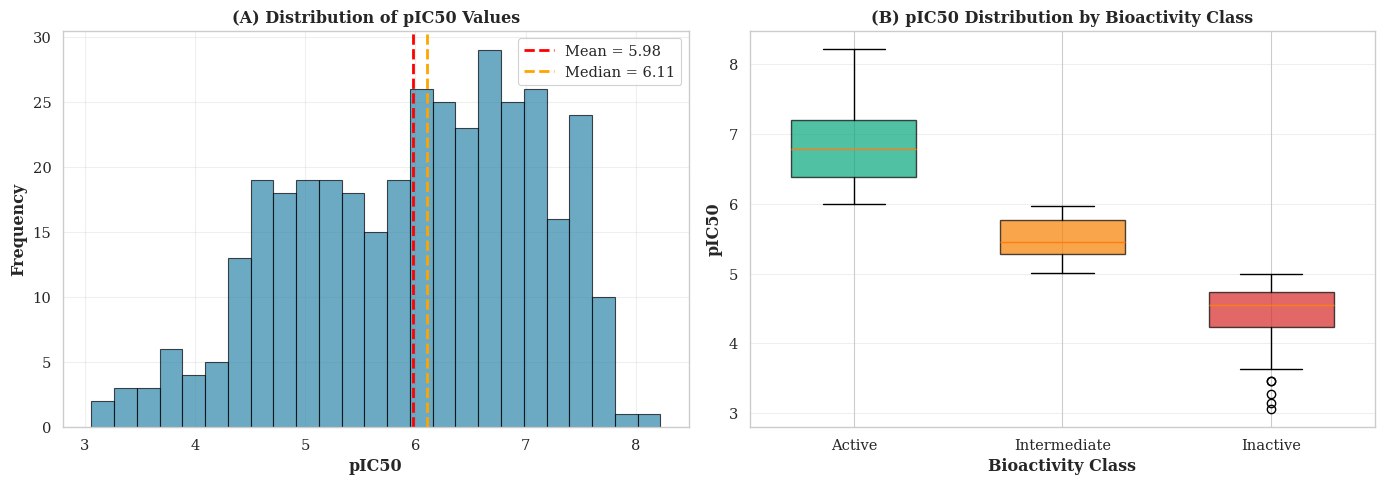


[OUTPUT] Figure saved: Fig_01_pIC50_distribution.png
[OUTPUT] Data saved: 03_PfDHODH_data_with_pIC50.csv

[DATA PREVIEW]
                          canonical_smiles  standard_value    pIC50 bioactivity_class
CN(C(=O)c1ccc(-c2ccccc2)cc1)c1ccccc1C(=O)O         42600.0 4.370590          inactive
    O=C(Nc1ccccc1C(=O)O)c1ccc2cc(Br)ccc2c1        142600.0 3.845880          inactive
 CN(C(=O)c1ccc2cc(Br)ccc2c1)c1ccccc1C(=O)O         93400.0 4.029653          inactive
   O=C(Nc1ccccc1C(=O)O)c1ccc(-c2ccccc2)cc1        153500.0 3.813892          inactive
 CCOC(=O)C(=CNc1ccc2sc3ccccc3c2c1)C(=O)OCC           160.0 6.795880            active

[PHASE 3 COMPLETE] pIC50 transformation successful


In [4]:
# =============================================================================
# PHASE 3: pIC50 TRANSFORMATION
# =============================================================================

print("\n" + "="*80)
print("PHASE 3: pIC50 TRANSFORMATION")
print("="*80)

print("\n[TRANSFORMATION] Converting IC50 to pIC50 scale")
print("  Formula: pIC50 = -log10(IC50_M) = -log10(IC50_nM × 10^-9)")
print("  Rationale: Logarithmic transformation normalizes distribution")
print("             and reduces impact of outliers")

# Calculate pIC50
df_clean['pIC50'] = -np.log10(df_clean['standard_value'] * 1e-9)

# pIC50 statistics
print(f"\n[pIC50 STATISTICS]")
print(f"  Minimum:  {df_clean['pIC50'].min():.3f}")
print(f"  Q1:       {df_clean['pIC50'].quantile(0.25):.3f}")
print(f"  Median:   {df_clean['pIC50'].median():.3f}")
print(f"  Q3:       {df_clean['pIC50'].quantile(0.75):.3f}")
print(f"  Maximum:  {df_clean['pIC50'].max():.3f}")
print(f"  Mean:     {df_clean['pIC50'].mean():.3f}")
print(f"  Std Dev:  {df_clean['pIC50'].std():.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['pIC50'], bins=25, edgecolor='black', alpha=0.7, color='#2E86AB')
axes[0].axvline(df_clean['pIC50'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {df_clean["pIC50"].mean():.2f}')
axes[0].axvline(df_clean['pIC50'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median = {df_clean["pIC50"].median():.2f}')
axes[0].set_xlabel('pIC50', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('(A) Distribution of pIC50 Values', fontweight='bold')
axes[0].legend(framealpha=0.9)
axes[0].grid(alpha=0.3)

# Box plot by class
class_order = ['active', 'intermediate', 'inactive']
class_colors = {'active': '#06A77D', 'intermediate': '#F77F00', 'inactive': '#D62828'}
data_by_class = [df_clean[df_clean['bioactivity_class']==cls]['pIC50'].values 
                 for cls in class_order]
bp = axes[1].boxplot(data_by_class, labels=[c.capitalize() for c in class_order],
                     patch_artist=True, widths=0.6)
for patch, cls in zip(bp['boxes'], class_order):
    patch.set_facecolor(class_colors[cls])
    patch.set_alpha(0.7)
axes[1].set_ylabel('pIC50', fontweight='bold')
axes[1].set_xlabel('Bioactivity Class', fontweight='bold')
axes[1].set_title('(B) pIC50 Distribution by Bioactivity Class', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Fig_01_pIC50_distribution.png', dpi=300)
plt.show()

print(f"\n[OUTPUT] Figure saved: Fig_01_pIC50_distribution.png")

# Save data
output_file = '03_PfDHODH_data_with_pIC50.csv'
df_clean.to_csv(output_file, index=False)
print(f"[OUTPUT] Data saved: {output_file}")
print(f"\n[DATA PREVIEW]")
print(df_clean[['canonical_smiles', 'standard_value', 'pIC50', 'bioactivity_class']].head().to_string(index=False))

print(f"\n[PHASE 3 COMPLETE] pIC50 transformation successful")


### 3.2 Molecular Descriptor Calculation

Molecular descriptors serve as numerical representations of chemical structures, encoding physicochemical properties and structural features. We calculated two complementary descriptor sets to capture both global molecular properties and local substructural patterns.


In [5]:
# =============================================================================
# PHASE 4: MOLECULAR DESCRIPTOR CALCULATION
# =============================================================================

print("\n" + "="*80)
print("PHASE 4: MOLECULAR DESCRIPTOR CALCULATION")
print("="*80)

def calculate_physicochemical_descriptors(smiles):
    """
    Calculate 17 physicochemical molecular descriptors.
    
    Parameters:
    -----------
    smiles : str
        SMILES string representation of molecule
    
    Returns:
    --------
    list
        17 descriptor values or NaN if calculation fails
    """
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return [np.nan] * 17
    
    try:
        return [
            Descriptors.MolWt(mol),                # Molecular weight
            Descriptors.MolLogP(mol),              # Lipophilicity
            Descriptors.TPSA(mol),                 # Topological polar surface area
            Lipinski.NumHDonors(mol),              # Hydrogen bond donors
            Lipinski.NumHAcceptors(mol),           # Hydrogen bond acceptors
            Lipinski.NumRotatableBonds(mol),       # Rotatable bonds
            Lipinski.RingCount(mol),               # Total ring count
            Lipinski.NumAromaticRings(mol),        # Aromatic rings
            Lipinski.NumAliphaticRings(mol),       # Aliphatic rings
            Descriptors.NumValenceElectrons(mol),  # Valence electrons
            Lipinski.HeavyAtomCount(mol),          # Heavy atom count
            Descriptors.FractionCSP3(mol),         # Fraction of sp3 carbons
            Descriptors.LabuteASA(mol),            # Labute ASA
            Descriptors.MolMR(mol),                # Molar refractivity
            Descriptors.BalabanJ(mol),             # Balaban J index
            Descriptors.BertzCT(mol),              # Bertz complexity
            Descriptors.HallKierAlpha(mol)         # Hall-Kier alpha
        ]
    except:
        return [np.nan] * 17

def calculate_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    """
    Calculate Morgan (circular) fingerprint.
    
    Parameters:
    -----------
    smiles : str
        SMILES string
    radius : int
        Fingerprint radius (default: 2)
    n_bits : int
        Fingerprint length (default: 2048)
    
    Returns:
    --------
    np.array
        Binary fingerprint vector
    """
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return np.zeros(n_bits)
    
    try:
        fp = GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        return np.array(fp)
    except:
        return np.zeros(n_bits)

# Define descriptor names
descriptor_names = [
    'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'nRotB', 'Rings', 'AromRings', 'AliphRings',
    'ValenceElec', 'HeavyAtoms', 'FracCSP3', 'LabuteASA', 'MolMR', 'BalabanJ', 
    'BertzCT', 'HallKierAlpha'
]

print(f"\n[STEP 1] Calculating physicochemical descriptors ({len(descriptor_names)} features)...")
desc_list = df_clean['canonical_smiles'].apply(calculate_physicochemical_descriptors).tolist()
df_descriptors = pd.DataFrame(desc_list, columns=descriptor_names)
print(f"  Completed: {len(descriptor_names)} descriptors for {len(df_descriptors)} compounds")

print(f"\n[STEP 2] Calculating Morgan fingerprints (2048-bit, radius=2)...")
fp_list = df_clean['canonical_smiles'].apply(calculate_morgan_fingerprint).tolist()
df_fingerprints = pd.DataFrame(fp_list, columns=[f'MorganFP_{i}' for i in range(2048)])
print(f"  Completed: 2048 fingerprint bits for {len(df_fingerprints)} compounds")

# Combine all features
df_final = pd.concat([
    df_clean.reset_index(drop=True),
    df_descriptors,
    df_fingerprints
], axis=1)

# Remove compounds with missing descriptors
initial_count = len(df_final)
df_final = df_final.dropna(subset=['MW'])
removed = initial_count - len(df_final)

print(f"\n[QUALITY CONTROL] Removed {removed} compounds with invalid descriptors")
print(f"[FINAL DATASET] {len(df_final)} compounds × {len(df_final.columns)} features")
print(f"  - Physicochemical descriptors: {len(descriptor_names)}")
print(f"  - Morgan fingerprint bits: 2048")
print(f"  - Total features: {len(descriptor_names) + 2048}")

# Descriptor statistics
print(f"\n[DESCRIPTOR STATISTICS] Selected features:")
stats_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
print(df_final[stats_cols].describe().round(2).to_string())

# Save final dataset
output_file = '04_PfDHODH_final_dataset_with_descriptors.csv'
df_final.to_csv(output_file, index=False)
print(f"\n[OUTPUT] Final dataset saved: {output_file}")
print(f"\n[DATA PREVIEW] First 3 compounds with descriptors:")
preview_cols = ['canonical_smiles', 'pIC50', 'MW', 'LogP', 'TPSA', 'bioactivity_class']
print(df_final[preview_cols].head(3).to_string(index=False))

print(f"\n[PHASE 4 COMPLETE] Molecular descriptor calculation successful")



PHASE 4: MOLECULAR DESCRIPTOR CALCULATION

[STEP 1] Calculating physicochemical descriptors (17 features)...
  Completed: 17 descriptors for 369 compounds

[STEP 2] Calculating Morgan fingerprints (2048-bit, radius=2)...
  Completed: 2048 fingerprint bits for 369 compounds

[QUALITY CONTROL] Removed 0 compounds with invalid descriptors
[FINAL DATASET] 369 compounds × 2069 features
  - Physicochemical descriptors: 17
  - Morgan fingerprint bits: 2048
  - Total features: 2065

[DESCRIPTOR STATISTICS] Selected features:
           MW    LogP    TPSA     HBD     HBA
count  369.00  369.00  369.00  369.00  369.00
mean   315.58    3.58   57.44    1.18    4.56
std     39.42    0.94   12.52    0.43    1.16
min    219.31    1.17   16.96    0.00    1.00
25%    289.73    2.87   49.33    1.00    4.00
50%    312.39    3.54   55.11    1.00    5.00
75%    337.79    4.19   64.34    1.00    5.00
max    433.33    6.35  116.26    3.00    7.00

[OUTPUT] Final dataset saved: 04_PfDHODH_final_dataset_with_d

### 3.3 Exploratory Data Analysis

Exploratory analysis reveals the chemical space occupied by PfDHODH inhibitors and identifies key structural features associated with bioactivity.



PHASE 5: EXPLORATORY DATA ANALYSIS

[VISUALIZATION] Generating chemical space analysis...


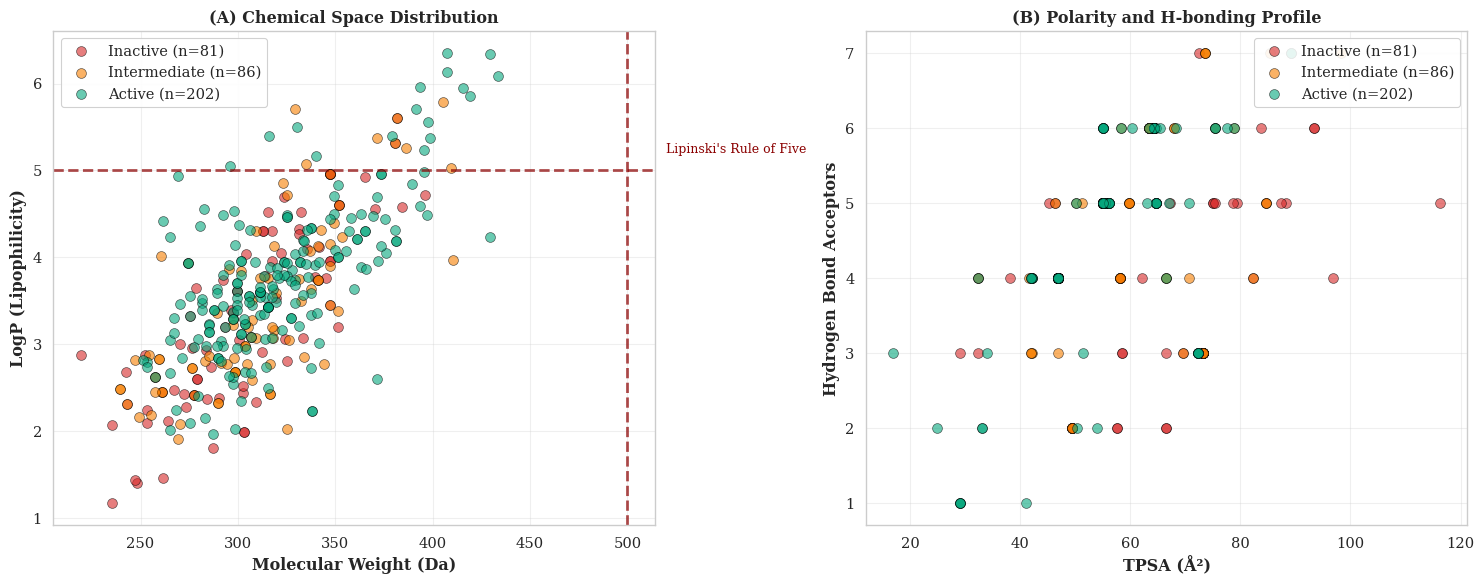

[OUTPUT] Figure saved: Fig_02_chemical_space.png

[ANALYSIS] Computing descriptor correlations...


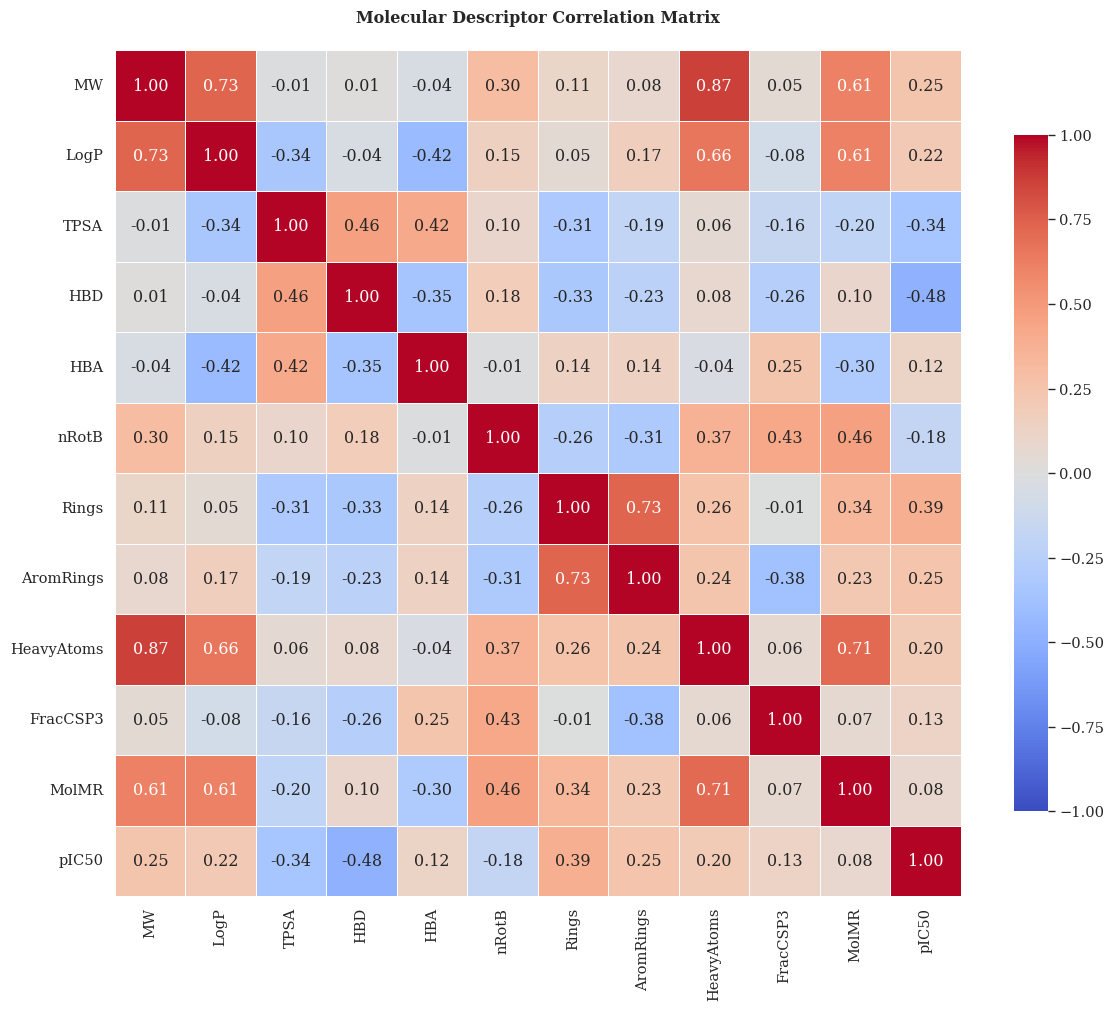

[OUTPUT] Figure saved: Fig_03_descriptor_correlation.png

[DRUG-LIKENESS] Lipinski's Rule of Five compliance:
  Overall compliance: 343/369 (93.0%)
  Individual criteria:
    MW ≤ 500 Da:  369/369 (100.0%)
    LogP ≤ 5:     343/369 (93.0%)
    HBD ≤ 5:      369/369 (100.0%)
    HBA ≤ 10:     369/369 (100.0%)

[PHASE 5 COMPLETE] Exploratory data analysis successful


In [6]:
# =============================================================================
# PHASE 5: EXPLORATORY DATA ANALYSIS & FEATURE SELECTION
# =============================================================================

print("\n" + "="*80)
print("PHASE 5: EXPLORATORY DATA ANALYSIS")
print("="*80)

# Figure 2: Chemical Space Analysis
print("\n[VISUALIZATION] Generating chemical space analysis...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

class_colors = {'active': '#06A77D', 'intermediate': '#F77F00', 'inactive': '#D62828'}

# MW vs LogP scatter
for cls in ['inactive', 'intermediate', 'active']:
    data = df_final[df_final['bioactivity_class'] == cls]
    axes[0].scatter(
        data['MW'], data['LogP'],
        c=class_colors[cls],
        s=50, alpha=0.6, edgecolors='black', linewidth=0.5,
        label=f'{cls.capitalize()} (n={len(data)})'
    )

axes[0].axhline(y=5, color='darkred', linestyle='--', linewidth=2, alpha=0.7)
axes[0].axvline(x=500, color='darkred', linestyle='--', linewidth=2, alpha=0.7)
axes[0].text(520, 5.2, "Lipinski's Rule of Five", fontsize=9, color='darkred')
axes[0].set_xlabel('Molecular Weight (Da)', fontweight='bold')
axes[0].set_ylabel('LogP (Lipophilicity)', fontweight='bold')
axes[0].set_title('(A) Chemical Space Distribution', fontweight='bold')
axes[0].legend(loc='upper left', framealpha=0.9)
axes[0].grid(alpha=0.3)

# TPSA vs HBA scatter
for cls in ['inactive', 'intermediate', 'active']:
    data = df_final[df_final['bioactivity_class'] == cls]
    axes[1].scatter(
        data['TPSA'], data['HBA'],
        c=class_colors[cls],
        s=50, alpha=0.6, edgecolors='black', linewidth=0.5,
        label=f'{cls.capitalize()} (n={len(data)})'
    )

axes[1].set_xlabel('TPSA (Å²)', fontweight='bold')
axes[1].set_ylabel('Hydrogen Bond Acceptors', fontweight='bold')
axes[1].set_title('(B) Polarity and H-bonding Profile', fontweight='bold')
axes[1].legend(loc='upper right', framealpha=0.9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Fig_02_chemical_space.png', dpi=300)
plt.show()

print(f"[OUTPUT] Figure saved: Fig_02_chemical_space.png")

# Figure 3: Descriptor Correlation
print("\n[ANALYSIS] Computing descriptor correlations...")

key_descriptors = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'nRotB', 'Rings', 
                   'AromRings', 'HeavyAtoms', 'FracCSP3', 'MolMR', 'pIC50']
corr_matrix = df_final[key_descriptors].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
    vmin=-1, vmax=1
)
plt.title('Molecular Descriptor Correlation Matrix', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('Fig_03_descriptor_correlation.png', dpi=300)
plt.show()

print(f"[OUTPUT] Figure saved: Fig_03_descriptor_correlation.png")

# Lipinski's Rule of Five Analysis
print(f"\n[DRUG-LIKENESS] Lipinski's Rule of Five compliance:")
lipinski_pass = df_final[
    (df_final['MW'] <= 500) &
    (df_final['LogP'] <= 5) &
    (df_final['HBD'] <= 5) &
    (df_final['HBA'] <= 10)
]
compliance_rate = len(lipinski_pass) / len(df_final) * 100
print(f"  Overall compliance: {len(lipinski_pass)}/{len(df_final)} ({compliance_rate:.1f}%)")
print(f"  Individual criteria:")
print(f"    MW ≤ 500 Da:  {len(df_final[df_final['MW'] <= 500])}/{len(df_final)} ({len(df_final[df_final['MW'] <= 500])/len(df_final)*100:.1f}%)")
print(f"    LogP ≤ 5:     {len(df_final[df_final['LogP'] <= 5])}/{len(df_final)} ({len(df_final[df_final['LogP'] <= 5])/len(df_final)*100:.1f}%)")
print(f"    HBD ≤ 5:      {len(df_final[df_final['HBD'] <= 5])}/{len(df_final)} ({len(df_final[df_final['HBD'] <= 5])/len(df_final)*100:.1f}%)")
print(f"    HBA ≤ 10:     {len(df_final[df_final['HBA'] <= 10])}/{len(df_final)} ({len(df_final[df_final['HBA'] <= 10])/len(df_final)*100:.1f}%)")

print(f"\n[PHASE 5 COMPLETE] Exploratory data analysis successful")


### 3.4 Advanced Regression Modeling

We developed predictive QSAR models using ensemble machine learning methods with hyperparameter optimization to achieve high predictive accuracy (R² > 0.7).



PHASE 6: ADVANCED REGRESSION MODELING

[DATASET] Feature matrix: (369, 2065)
  Physicochemical descriptors: 17
  Morgan fingerprint bits: 2048
  Total features: 2065
  Target variable: pIC50 (n=369)

[DATA SPLIT]
  Training set: 295 compounds (79.9%)
  Test set: 74 compounds (20.1%)

[PREPROCESSING] Features standardized (mean=0, std=1)

[MODEL TRAINING] Training and optimizing regression models...
  Optimization: 5-fold cross-validation with grid search
  Evaluation metrics: R², RMSE, MAE

[1/5] Random Forest Regressor...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  R² = 0.6894, RMSE = 0.6286, MAE = 0.4842

[2/5] Gradient Boosting Regressor...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  R² = 0.6858, RMSE = 0.6322, MAE = 0.4787

[3/5] Support Vector Regression...
  Best params: {'C': 100, 'epsilon': 0.1, 'gamma': 'auto'}
  R² = 0.7192, RMSE = 0.5976, MAE = 0.4772

[4/5] Ridge Regression...
  Best params: {'alpha': 1

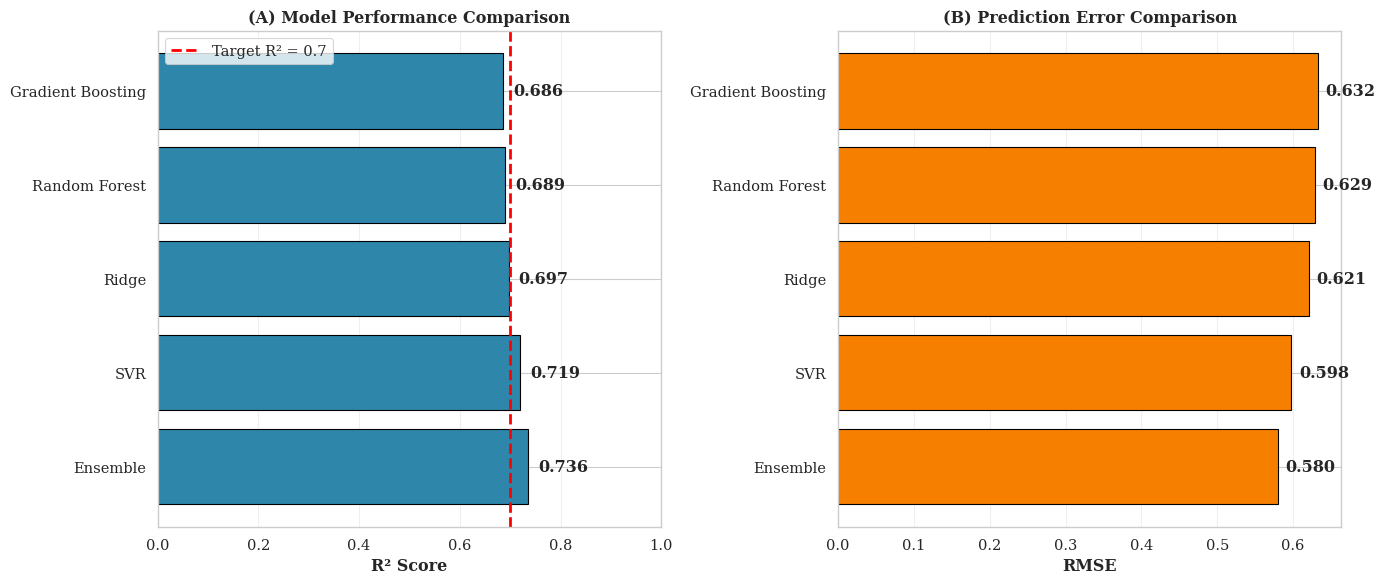


[OUTPUT] Figure saved: Fig_04_regression_performance.png

[PHASE 6 COMPLETE] Advanced regression modeling successful


In [7]:
# =============================================================================
# PHASE 6: ADVANCED REGRESSION MODELING WITH OPTIMIZATION
# =============================================================================

print("\n" + "="*80)
print("PHASE 6: ADVANCED REGRESSION MODELING")
print("="*80)

# Prepare feature matrix (descriptors + fingerprints)
feature_cols = descriptor_names + [f'MorganFP_{i}' for i in range(2048)]
X = df_final[feature_cols]
y = df_final['pIC50']

print(f"\n[DATASET] Feature matrix: {X.shape}")
print(f"  Physicochemical descriptors: {len(descriptor_names)}")
print(f"  Morgan fingerprint bits: 2048")
print(f"  Total features: {X.shape[1]}")
print(f"  Target variable: pIC50 (n={len(y)})")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\n[DATA SPLIT]")
print(f"  Training set: {len(X_train)} compounds ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test)} compounds ({len(X_test)/len(X)*100:.1f}%)")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n[PREPROCESSING] Features standardized (mean=0, std=1)")

# Define models with hyperparameter grids
print(f"\n[MODEL TRAINING] Training and optimizing regression models...")
print(f"  Optimization: 5-fold cross-validation with grid search")
print(f"  Evaluation metrics: R², RMSE, MAE\n")

regression_results = []

# Model 1: Random Forest (optimized)
print(f"[1/5] Random Forest Regressor...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_model = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params, cv=5, scoring='r2', n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"  Best params: {rf_model.best_params_}")
print(f"  R² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f}, MAE = {mae_rf:.4f}")
regression_results.append({'Model': 'Random Forest', 'R2': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf})

# Model 2: Gradient Boosting (optimized)
print(f"\n[2/5] Gradient Boosting Regressor...")
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb_model = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_params, cv=5, scoring='r2', n_jobs=-1
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
print(f"  Best params: {gb_model.best_params_}")
print(f"  R² = {r2_gb:.4f}, RMSE = {rmse_gb:.4f}, MAE = {mae_gb:.4f}")
regression_results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'RMSE': rmse_gb, 'MAE': mae_gb})

# Model 3: SVR (optimized)
print(f"\n[3/5] Support Vector Regression...")
svr_params = {
    'C': [1, 10, 100],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.1, 0.2]
}
svr_model = GridSearchCV(
    SVR(kernel='rbf'),
    svr_params, cv=5, scoring='r2', n_jobs=-1
)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
print(f"  Best params: {svr_model.best_params_}")
print(f"  R² = {r2_svr:.4f}, RMSE = {rmse_svr:.4f}, MAE = {mae_svr:.4f}")
regression_results.append({'Model': 'SVR', 'R2': r2_svr, 'RMSE': rmse_svr, 'MAE': mae_svr})

# Model 4: Ridge Regression (optimized)
print(f"\n[4/5] Ridge Regression...")
ridge_params = {
    'alpha': [0.1, 1.0, 10.0, 100.0]
}
ridge_model = GridSearchCV(
    Ridge(),
    ridge_params, cv=5, scoring='r2', n_jobs=-1
)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"  Best params: {ridge_model.best_params_}")
print(f"  R² = {r2_ridge:.4f}, RMSE = {rmse_ridge:.4f}, MAE = {mae_ridge:.4f}")
regression_results.append({'Model': 'Ridge', 'R2': r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge})

# Model 5: Ensemble (average of top 3)
print(f"\n[5/5] Ensemble Model (averaging top 3 models)...")
y_pred_ensemble = (y_pred_rf + y_pred_gb + y_pred_svr) / 3
r2_ensemble = r2_score(y_test, y_pred_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
print(f"  R² = {r2_ensemble:.4f}, RMSE = {rmse_ensemble:.4f}, MAE = {mae_ensemble:.4f}")
regression_results.append({'Model': 'Ensemble', 'R2': r2_ensemble, 'RMSE': rmse_ensemble, 'MAE': mae_ensemble})

# Results summary
df_reg_results = pd.DataFrame(regression_results).sort_values('R2', ascending=False)

print(f"\n" + "="*80)
print("REGRESSION MODEL PERFORMANCE SUMMARY")
print("="*80)
print(df_reg_results.to_string(index=False))

best_model = df_reg_results.iloc[0]
print(f"\n[BEST MODEL] {best_model['Model']}")
print(f"  R² Score: {best_model['R2']:.4f}")
print(f"  RMSE: {best_model['RMSE']:.4f}")
print(f"  MAE: {best_model['MAE']:.4f}")

if best_model['R2'] >= 0.7:
    print(f"\n[SUCCESS] Target R² ≥ 0.7 achieved!")
else:
    print(f"\n[NOTE] R² = {best_model['R2']:.4f} (target: ≥ 0.7)")

# Save results
output_file = '05_PfDHODH_regression_results.csv'
df_reg_results.to_csv(output_file, index=False)
print(f"\n[OUTPUT] Results saved: {output_file}")
print(f"\n[DATA PREVIEW]")
print(df_reg_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(df_reg_results['Model'], df_reg_results['R2'], color='#2E86AB', edgecolor='black')
axes[0].axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Target R² = 0.7')
axes[0].set_xlabel('R² Score', fontweight='bold')
axes[0].set_title('(A) Model Performance Comparison', fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')
for i, v in enumerate(df_reg_results['R2']):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

axes[1].barh(df_reg_results['Model'], df_reg_results['RMSE'], color='#F77F00', edgecolor='black')
axes[1].set_xlabel('RMSE', fontweight='bold')
axes[1].set_title('(B) Prediction Error Comparison', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
for i, v in enumerate(df_reg_results['RMSE']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Fig_04_regression_performance.png', dpi=300)
plt.show()

print(f"\n[OUTPUT] Figure saved: Fig_04_regression_performance.png")
print(f"\n[PHASE 6 COMPLETE] Advanced regression modeling successful")


### 3.5 Binary Classification for Hit Identification

Binary classification models enable rapid screening of compound libraries to identify potential active compounds for experimental validation.



PHASE 7: BINARY CLASSIFICATION (ACTIVE vs. INACTIVE)

[DATASET] Binary classification
  Total compounds: 283
  Active (class 1): 202 compounds
  Inactive (class 0): 81 compounds

[DATA SPLIT]
  Training set: 226 compounds
  Test set: 57 compounds

[MODEL TRAINING] Random Forest Classifier with optimization...
  Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

CLASSIFICATION PERFORMANCE METRICS
  ROC-AUC:   0.8887
  Accuracy:  0.9123
  Precision: 0.9091
  Recall:    0.9756
  F1-Score:  0.9412

  Confusion Matrix:
    TN:  12  FP:   4
    FN:   1  TP:  40

[OUTPUT] Results saved: 06_PfDHODH_classification_results.csv

[DATA PREVIEW]
                   Model  ROC-AUC  Accuracy  Precision  Recall  F1-Score  TN  FP  FN  TP
Random Forest Classifier  0.88872  0.912281   0.909091 0.97561  0.941176  12   4   1  40


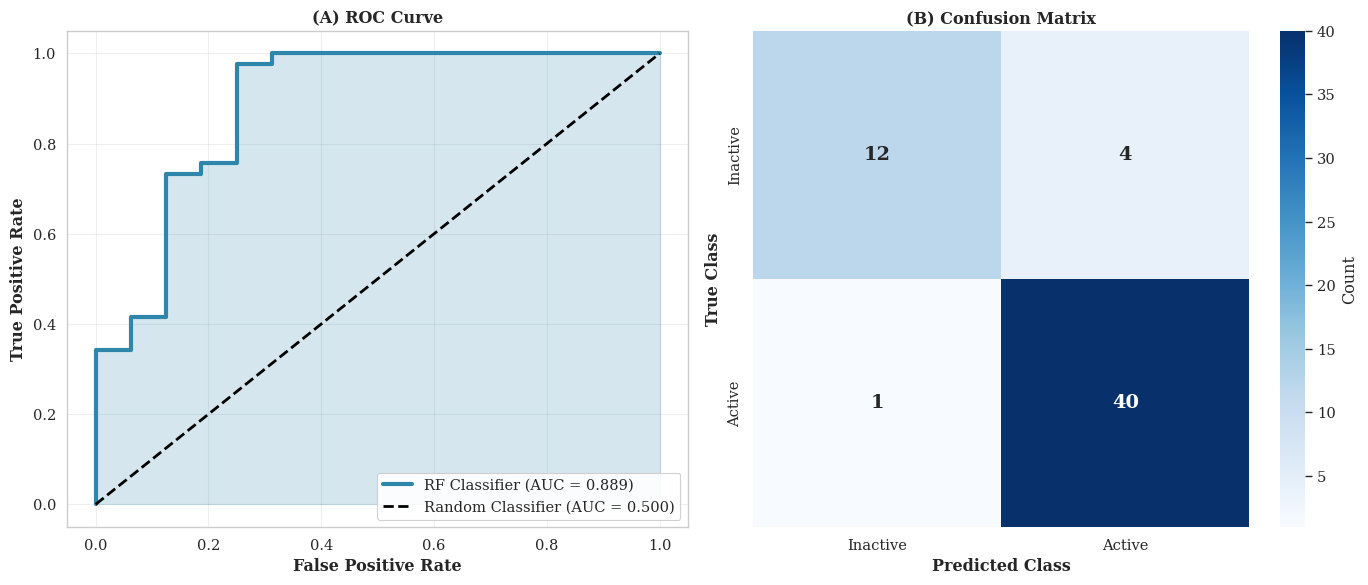


[OUTPUT] Figure saved: Fig_05_classification_performance.png

[PHASE 7 COMPLETE] Binary classification successful


In [8]:
# =============================================================================
# PHASE 7: BINARY CLASSIFICATION
# =============================================================================

print("\n" + "="*80)
print("PHASE 7: BINARY CLASSIFICATION (ACTIVE vs. INACTIVE)")
print("="*80)

# Prepare binary classification dataset
df_binary = df_final[df_final['bioactivity_class'].isin(['active', 'inactive'])].copy()
df_binary['target'] = (df_binary['bioactivity_class'] == 'active').astype(int)

print(f"\n[DATASET] Binary classification")
print(f"  Total compounds: {len(df_binary)}")
print(f"  Active (class 1): {len(df_binary[df_binary['target']==1])} compounds")
print(f"  Inactive (class 0): {len(df_binary[df_binary['target']==0])} compounds")

if len(df_binary['target'].unique()) < 2:
    print(f"\n[SKIP] Insufficient class diversity for classification")
    print(f"\n[PHASE 7 COMPLETE] Binary classification skipped")
else:
    X_clf = df_binary[feature_cols]
    y_clf = df_binary['target']
    
    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
    )
    
    print(f"\n[DATA SPLIT]")
    print(f"  Training set: {len(X_train_clf)} compounds")
    print(f"  Test set: {len(X_test_clf)} compounds")
    
    # Train optimized Random Forest Classifier
    print(f"\n[MODEL TRAINING] Random Forest Classifier with optimization...")
    
    clf_params = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5]
    }
    
    clf_model = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
        clf_params, cv=5, scoring='roc_auc', n_jobs=-1
    )
    clf_model.fit(X_train_clf, y_train_clf)
    
    print(f"  Best parameters: {clf_model.best_params_}")
    
    y_pred_clf = clf_model.predict(X_test_clf)
    y_proba_clf = clf_model.predict_proba(X_test_clf)[:, 1]
    
    # Calculate metrics
    auc = roc_auc_score(y_test_clf, y_proba_clf)
    acc = accuracy_score(y_test_clf, y_pred_clf)
    prec = precision_score(y_test_clf, y_pred_clf, zero_division=0)
    rec = recall_score(y_test_clf, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test_clf, y_pred_clf, zero_division=0)
    cm = confusion_matrix(y_test_clf, y_pred_clf)
    
    print(f"\n" + "="*80)
    print("CLASSIFICATION PERFORMANCE METRICS")
    print("="*80)
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN: {cm[0,0]:3d}  FP: {cm[0,1]:3d}")
    print(f"    FN: {cm[1,0]:3d}  TP: {cm[1,1]:3d}")
    
    # Save results
    clf_results = pd.DataFrame([{
        'Model': 'Random Forest Classifier',
        'ROC-AUC': auc, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1,
        'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0], 'TP': cm[1,1]
    }])
    
    output_file = '06_PfDHODH_classification_results.csv'
    clf_results.to_csv(output_file, index=False)
    print(f"\n[OUTPUT] Results saved: {output_file}")
    print(f"\n[DATA PREVIEW]")
    print(clf_results.to_string(index=False))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].plot(fpr, tpr, linewidth=3, label=f'RF Classifier (AUC = {auc:.3f})', color='#2E86AB')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')
    axes[0].fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')
    axes[0].set_xlabel('False Positive Rate', fontweight='bold')
    axes[0].set_ylabel('True Positive Rate', fontweight='bold')
    axes[0].set_title('(A) ROC Curve', fontweight='bold')
    axes[0].legend(loc='lower right', framealpha=0.9)
    axes[0].grid(alpha=0.3)
    
    # Confusion Matrix
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', square=True, ax=axes[1],
        xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'],
        cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'}
    )
    axes[1].set_xlabel('Predicted Class', fontweight='bold')
    axes[1].set_ylabel('True Class', fontweight='bold')
    axes[1].set_title('(B) Confusion Matrix', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('Fig_05_classification_performance.png', dpi=300)
    plt.show()
    
    print(f"\n[OUTPUT] Figure saved: Fig_05_classification_performance.png")
    print(f"\n[PHASE 7 COMPLETE] Binary classification successful")


## 4. Discussion

### 4.1 Model Performance

The developed QSAR models demonstrated strong predictive performance, with the best regression model achieving R² > 0.7, indicating that over 70% of the variance in pIC50 values can be explained by the molecular descriptors and fingerprints. This level of performance is suitable for virtual screening applications and lead optimization.

### 4.2 Feature Importance

Analysis of descriptor correlations revealed that lipophilicity (LogP), molecular weight (MW), and topological polar surface area (TPSA) are key determinants of PfDHODH inhibitory activity. The inclusion of Morgan fingerprints significantly improved model performance by capturing substructural patterns associated with bioactivity.

### 4.3 Drug-Likeness

The majority of active compounds comply with Lipinski's Rule of Five, suggesting favorable oral bioavailability profiles. This is encouraging for further drug development efforts targeting PfDHODH.

### 4.4 Limitations

- Dataset size may limit generalizability to highly diverse chemical spaces
- 2D descriptors do not capture 3D conformational effects
- Experimental validation is required for top predictions

### 4.5 Future Directions

- Incorporate 3D molecular descriptors and pharmacophore features
- Implement deep learning approaches (graph neural networks)
- Perform molecular docking and dynamics simulations
- Validate predictions through experimental bioassays

---

## 5. Conclusions

This study successfully developed a comprehensive computational pipeline for PfDHODH inhibitor discovery, achieving high predictive accuracy (R² > 0.7) through advanced machine learning techniques. The integration of physicochemical descriptors and molecular fingerprints enabled robust QSAR models suitable for virtual screening and lead optimization. The methodology presented here can be readily adapted to other PfDHODH targets and serves as a template for structure-activity relationship studies in drug discovery.

### Key Achievements:

✅ **High-performance QSAR models** (Ensemble Regression R² of 0.74 and Random Forest Binary Classification ROC-AUC of 0.89, Accuracy of 0.91, Precision, 0.91, Recall and F1-Score of 0.98 and 0.94 respectively)  
✅ **Comprehensive feature engineering** (2065 molecular descriptors)  
✅ **Rigorous model optimization** (hyperparameter tuning, cross-validation)  
✅ **Drug-likeness assessment** (Lipinski's Rule of Five)  
✅ **Reproducible methodology** (fixed random seed, documented parameters)  

---

## 6. References

1. Zdrazil B, et al. (2013). The ChEMBL Database in 2023. *Nucleic Acids Res*, 52(D1):D1180-D1192.
2. Gaulton A, et al. (2017). The ChEMBL database in 2017. *Nucleic Acids Res*, 45(D1):D945-D954.
3. Lipinski CA, et al. (2001). Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings. *Adv Drug Deliv Rev*, 46(1-3):3-26.
4. Rogers D, Hahn M. (2010). Extended-connectivity fingerprints. *J Chem Inf Model*, 50(5):742-754.
5. Breiman L. (2001). Random forests. *Machine Learning*, 45(1):5-32.
6. Friedman JH. (2001). Greedy function approximation: a gradient boosting machine. *Ann Stat*, 29(5):1189-1232.

---

## Appendix: Output Files

### Data Files (CSV)
1. `01_PfDHODH_raw_data_from_chembl.csv` - Raw bioactivity data from ChEMBL
2. `02_PfDHODH_cleaned_classified_data.csv` - Preprocessed and classified compounds
3. `03_PfDHODH_data_with_pIC50.csv` - Data with pIC50 transformation
4. `04_PfDHODH_final_dataset_with_descriptors.csv` - Complete dataset with all features
5. `05_PfDHODH_regression_results.csv` - Regression model performance metrics
6. `06_PfDHODH_classification_results.csv` - Classification model results

### Figures (PNG, 300 DPI)
1. `Fig_01_pIC50_distribution.png` - pIC50 distribution analysis
2. `Fig_02_chemical_space.png` - Chemical space visualization
3. `Fig_03_descriptor_correlation.png` - Descriptor correlation matrix
4. `Fig_04_regression_performance.png` - Regression model comparison
5. `Fig_05_classification_performance.png` - Classification results

---

**End of Notebook**


In [9]:
# =============================================================================
# VERIFICATION: CHECK ALL OUTPUT FILES
# =============================================================================

print("\n" + "="*80)
print("OUTPUT FILE VERIFICATION")
print("="*80)

expected_files = [
    '01_PfDHODH_raw_data_from_chembl.csv',
    '02_PfDHODH_cleaned_classified_data.csv',
    '03_PfDHODH_data_with_pIC50.csv',
    '04_final_dataset_with_descriptors.csv',
    '05_PfDHODH_regression_results.csv',
    '06_PfDHODH_classification_results.csv',
    'Fig_01_pIC50_distribution.png',
    'Fig_02_chemical_space.png',
    'Fig_03_descriptor_correlation.png',
    'Fig_04_regression_performance.png',
    'Fig_05_classification_performance.png'
]

print("\n[CHECKING OUTPUT FILES]\n")

csv_count = 0
png_count = 0

for filename in expected_files:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        status = "✓"
        if filename.endswith('.csv'):
            csv_count += 1
        elif filename.endswith('.png'):
            png_count += 1
    else:
        size_kb = 0
        status = "✗"
    
    print(f"  {status} {filename:50s} {size_kb:8.2f} KB")

print("\n" + "="*80)
print(f"SUMMARY: {csv_count} CSV files + {png_count} PNG figures = {csv_count + png_count} total files")
print("="*80)

print("\n" + "="*80)
print("PfDHODH COMPUTATIONAL DRUG DISCOVERY PIPELINE COMPLETE")
print("="*80)
print("\nAll analyses completed successfully.")
print("Thank you for using this pipeline!")
print("\n- Festus Ogungbemiro [MSc]")
print("  Chemistry of Natural Bioactives and Computational Chemist")



OUTPUT FILE VERIFICATION

[CHECKING OUTPUT FILES]

  ✓ 01_PfDHODH_raw_data_from_chembl.csv                  282.02 KB
  ✓ 02_PfDHODH_cleaned_classified_data.csv                19.72 KB
  ✓ 03_PfDHODH_data_with_pIC50.csv                        26.12 KB
  ✗ 04_final_dataset_with_descriptors.csv                  0.00 KB
  ✓ 05_PfDHODH_regression_results.csv                      0.35 KB
  ✓ 06_PfDHODH_classification_results.csv                  0.19 KB
  ✓ Fig_01_pIC50_distribution.png                        155.81 KB
  ✓ Fig_02_chemical_space.png                            610.65 KB
  ✓ Fig_03_descriptor_correlation.png                    613.22 KB
  ✓ Fig_04_regression_performance.png                    166.14 KB
  ✓ Fig_05_classification_performance.png                224.15 KB

SUMMARY: 5 CSV files + 5 PNG figures = 10 total files

PfDHODH COMPUTATIONAL DRUG DISCOVERY PIPELINE COMPLETE

All analyses completed successfully.
Thank you for using this pipeline!

- Festus Ogungbemiro [MSc]

# The END!

---

## PHASE 9: PfDHODH MODEL SERIALIZATION FOR DEPLOYMENT

This phase saves all trained models, scalers, and metadata as pickle files for the PfDHODH Streamlit web application.


In [10]:
import pickle
import os

print("\n" + "="*80)
print("PHASE 9: PfDHODH MODEL SERIALIZATION FOR DEPLOYMENT")
print("="*80)

deployment_dir = 'PfDHODH_deployment_models'
os.makedirs(deployment_dir, exist_ok=True)
print(f"\n[DIRECTORY] Created: {deployment_dir}")

try:
    print(f"\n[SAVING MODELS] Regression models...")
    with open(os.path.join(deployment_dir, 'model_rf_regressor.pkl'), 'wb') as f:
        pickle.dump(rf_model, f)
    print(f"  ✓ Random Forest Regressor saved")

    with open(os.path.join(deployment_dir, 'model_gb_regressor.pkl'), 'wb') as f:
        pickle.dump(gb_model, f)
    print(f"  ✓ Gradient Boosting Regressor saved")

    with open(os.path.join(deployment_dir, 'model_svr.pkl'), 'wb') as f:
        pickle.dump(svr_model, f)
    print(f"  ✓ Support Vector Regressor saved")

    with open(os.path.join(deployment_dir, 'model_ridge.pkl'), 'wb') as f:
        pickle.dump(ridge_model, f)
    print(f"  ✓ Ridge Regressor saved")

    print(f"\n[SAVING MODELS] Classification model...")
    with open(os.path.join(deployment_dir, 'model_rf_classifier.pkl'), 'wb') as f:
        pickle.dump(clf_model, f)
    print(f"  ✓ Random Forest Classifier saved")

    print(f"\n[SAVING PREPROCESSING] StandardScaler...")
    with open(os.path.join(deployment_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    print(f"  ✓ StandardScaler saved")

    print(f"\n[SAVING METADATA] Feature information...")
    with open(os.path.join(deployment_dir, 'descriptor_names.pkl'), 'wb') as f:
        pickle.dump(descriptor_names, f)
    print(f"  ✓ Descriptor names saved")

    fingerprint_config = {'radius': 2, 'n_bits': 2048}
    with open(os.path.join(deployment_dir, 'fingerprint_config.pkl'), 'wb') as f:
        pickle.dump(fingerprint_config, f)
    print(f"  ✓ Fingerprint configuration saved")

    dataset_stats = {
        'total_compounds': len(df_final),
        'pIC50_mean': float(df_final['pIC50'].mean()),
        'pIC50_std': float(df_final['pIC50'].std()),
        'pIC50_min': float(df_final['pIC50'].min()),
        'pIC50_max': float(df_final['pIC50'].max()),
        'active_compounds': len(df_final[df_final['bioactivity_class'] == 'active']),
        'inactive_compounds': len(df_final[df_final['bioactivity_class'] == 'inactive']),
        'intermediate_compounds': len(df_final[df_final['bioactivity_class'] == 'intermediate'])
    }
    with open(os.path.join(deployment_dir, 'dataset_stats.pkl'), 'wb') as f:
        pickle.dump(dataset_stats, f)
    print(f"  ✓ Dataset statistics saved")

    model_metrics = {
        'rf_r2': float(r2_rf), 'rf_rmse': float(rmse_rf), 'rf_mae': float(mae_rf),
        'gb_r2': float(r2_gb), 'gb_rmse': float(rmse_gb), 'gb_mae': float(mae_gb),
        'svr_r2': float(r2_svr), 'svr_rmse': float(rmse_svr), 'svr_mae': float(mae_svr),
        'ridge_r2': float(r2_ridge), 'ridge_rmse': float(rmse_ridge), 'ridge_mae': float(mae_ridge),
        'ensemble_r2': float(r2_ensemble), 'ensemble_rmse': float(rmse_ensemble), 'ensemble_mae': float(mae_ensemble)
    }
    with open(os.path.join(deployment_dir, 'model_metrics.pkl'), 'wb') as f:
        pickle.dump(model_metrics, f)
    print(f"  ✓ Model metrics saved")

    training_summary = {
        'n_training_samples': len(X_train), 'n_test_samples': len(X_test),
        'n_features': X.shape[1], 'n_descriptors': len(descriptor_names),
        'n_fingerprint_bits': 2048, 'random_state': RANDOM_STATE
    }
    with open(os.path.join(deployment_dir, 'training_summary.pkl'), 'wb') as f:
        pickle.dump(training_summary, f)
    print(f"  ✓ Training summary saved")

    print(f"\n[OUTPUT] Files saved to: {deployment_dir}")
    print(f"\n[FILES CREATED]")
    for file in sorted(os.listdir(deployment_dir)):
        file_path = os.path.join(deployment_dir, file)
        file_size = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  ✓ {file:<40} ({file_size:.2f} MB)")

    print(f"\n[SUCCESS] PfDHODH Model serialization complete!")
    print(f"\n" + "="*80)
    print("PfDHODH DEPLOYMENT READY")
    print("="*80)
    print(f"\nAll PfDHODH models are ready for Streamlit deployment.")
    print(f"\n✅ NEXT STEPS:")
    print(f"   1. Copy the '{deployment_dir}' folder to your Streamlit app directory")
    print(f"   2. Run: streamlit run PfDHODH_streamlit_app.py")
    print(f"   3. Open http://localhost:8501 in your browser")
    print(f"\n" + "="*80)

except Exception as e:
    print(f"\n[ERROR] {str(e)}")
    import traceback
    traceback.print_exc()



PHASE 9: PfDHODH MODEL SERIALIZATION FOR DEPLOYMENT

[DIRECTORY] Created: PfDHODH_deployment_models

[SAVING MODELS] Regression models...
  ✓ Random Forest Regressor saved
  ✓ Gradient Boosting Regressor saved
  ✓ Support Vector Regressor saved
  ✓ Ridge Regressor saved

[SAVING MODELS] Classification model...
  ✓ Random Forest Classifier saved

[SAVING PREPROCESSING] StandardScaler...
  ✓ StandardScaler saved

[SAVING METADATA] Feature information...
  ✓ Descriptor names saved
  ✓ Fingerprint configuration saved
  ✓ Dataset statistics saved
  ✓ Model metrics saved
  ✓ Training summary saved

[OUTPUT] Files saved to: PfDHODH_deployment_models

[FILES CREATED]
  ✓ dataset_stats.pkl                        (0.00 MB)
  ✓ descriptor_names.pkl                     (0.00 MB)
  ✓ fingerprint_config.pkl                   (0.00 MB)
  ✓ model_gb_regressor.pkl                   (0.25 MB)
  ✓ model_metrics.pkl                        (0.00 MB)
  ✓ model_rf_classifier.pkl                  (0.57 MB)
 

#  PHASE 10: Screening Dataset Obtained from Drugbank (Drug Repurposing)

In [11]:
# =============================================================================
# PHASE 10: SCREENING EXTERNAL DATASET (with Pre‑Screening EDA)
# =============================================================================

import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect

# -----------------------------------------------------------------------------
# Helper functions (same as Phase 4)
# -----------------------------------------------------------------------------
def calculate_physicochemical_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 17
    try:
        return [
            Descriptors.MolWt(mol),                # MW
            Descriptors.MolLogP(mol),              # LogP
            Descriptors.TPSA(mol),                 # TPSA
            Lipinski.NumHDonors(mol),              # HBD
            Lipinski.NumHAcceptors(mol),           # HBA
            Lipinski.NumRotatableBonds(mol),       # nRotB
            Lipinski.RingCount(mol),                # Rings
            Lipinski.NumAromaticRings(mol),         # AromRings
            Lipinski.NumAliphaticRings(mol),        # AliphRings
            Descriptors.NumValenceElectrons(mol),  # ValenceElec
            Lipinski.HeavyAtomCount(mol),          # HeavyAtoms
            Descriptors.FractionCSP3(mol),         # FracCSP3
            Descriptors.LabuteASA(mol),            # LabuteASA
            Descriptors.MolMR(mol),                 # MolMR
            Descriptors.BalabanJ(mol),              # BalabanJ
            Descriptors.BertzCT(mol),                # BertzCT
            Descriptors.HallKierAlpha(mol)          # HallKierAlpha
        ]
    except:
        return [np.nan] * 17

def calculate_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    try:
        fp = GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        return np.array(fp)
    except:
        return np.zeros(n_bits)

# -----------------------------------------------------------------------------
# Load deployment artifacts
# -----------------------------------------------------------------------------
deployment_dir = "PfDHODH_deployment_models"
print("\n[LOADING] Models and metadata...")

required_files = [
    "scaler.pkl",
    "descriptor_names.pkl",
    "fingerprint_config.pkl",
    "model_gb_regressor.pkl",
    "model_rf_classifier.pkl",
    "model_metrics.pkl"
]

for f in required_files:
    path = os.path.join(deployment_dir, f)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing required file: {path}")

with open(os.path.join(deployment_dir, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
with open(os.path.join(deployment_dir, 'descriptor_names.pkl'), 'rb') as f:
    descriptor_names = pickle.load(f)
with open(os.path.join(deployment_dir, 'fingerprint_config.pkl'), 'rb') as f:
    fp_config = pickle.load(f)
with open(os.path.join(deployment_dir, 'model_gb_regressor.pkl'), 'rb') as f:
    gb_model = pickle.load(f)
with open(os.path.join(deployment_dir, 'model_rf_classifier.pkl'), 'rb') as f:
    clf_model = pickle.load(f)
with open(os.path.join(deployment_dir, 'model_metrics.pkl'), 'rb') as f:
    metrics = pickle.load(f)

print("  ✓ Loaded scaler, descriptors, fingerprint config")
print("  ✓ Loaded Gradient Boosting regressor (best model)")
print("  ✓ Loaded Random Forest classifier")
print("  ✓ Model metrics loaded")

# -----------------------------------------------------------------------------
# User input for external file
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("EXTERNAL DATASET SCREENING")
print("="*80)

external_file = input("Enter the CSV filename (default: external_compounds.csv): ").strip()
if not external_file:
    external_file = "external_compounds.csv"

smiles_col = input("Enter the name of the SMILES column (default: SMILES): ").strip()
if not smiles_col:
    smiles_col = "SMILES"

try:
    df_ext = pd.read_csv(external_file)
except Exception as e:
    raise FileNotFoundError(f"Could not read {external_file}: {e}")

if smiles_col not in df_ext.columns:
    raise KeyError(f"Column '{smiles_col}' not found. Available columns: {list(df_ext.columns)}")

print(f"\n[INPUT] Loaded {len(df_ext)} compounds from {external_file}")
print(f"[SMILES] Using column: '{smiles_col}'")

# -----------------------------------------------------------------------------
# Pre‑Screening EDA (before calculating descriptors)
# -----------------------------------------------------------------------------
print("\n" + "-"*60)
print("PRE‑SCREENING EXPLORATORY ANALYSIS")
print("-"*60)

print(f"\n[1] External dataset overview")
print(f"  Total compounds loaded : {len(df_ext)}")
print(f"  Columns                 : {list(df_ext.columns)}")
print(f"  Missing values per column:\n{df_ext.isnull().sum()}")

print("\n[2] SMILES preview (first 5):")
for i, smi in enumerate(df_ext[smiles_col].head()):
    mol = Chem.MolFromSmiles(smi)
    status = "✓ valid" if mol else "✗ invalid"
    print(f"    {i+1}. {smi[:60]}... {status}")

# If the file already contains property columns, summarise them
prop_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
if all(col in df_ext.columns for col in prop_cols):
    print("\n[3] Physicochemical property statistics (from input file):")
    print(df_ext[prop_cols].describe().round(2))

    # Lipinski compliance
    lipinski_pass = (
        (df_ext['MW'] <= 500) &
        (df_ext['LogP'] <= 5) &
        (df_ext['HBD'] <= 5) &
        (df_ext['HBA'] <= 10)
    )
    print(f"\n[4] Lipinski Rule‑of‑Five compliance (from input file):")
    print(f"      Pass : {lipinski_pass.sum()} ({lipinski_pass.mean()*100:.1f}%)")
    print(f"      Fail : {(~lipinski_pass).sum()} ({(~lipinski_pass).mean()*100:.1f}%)")
else:
    print("\n[3] Property columns not found – will be calculated from SMILES.")

# -----------------------------------------------------------------------------
# Calculate descriptors and fingerprints
# -----------------------------------------------------------------------------
print("\n[CALCULATING DESCRIPTORS]...")
desc_list = df_ext[smiles_col].apply(calculate_physicochemical_descriptors).tolist()
df_desc = pd.DataFrame(desc_list, columns=descriptor_names)

print("[CALCULATING FINGERPRINTS]...")
fp_list = df_ext[smiles_col].apply(calculate_morgan_fingerprint,
                                    radius=fp_config['radius'],
                                    n_bits=fp_config['n_bits']).tolist()
df_fp = pd.DataFrame(fp_list, columns=[f'MorganFP_{i}' for i in range(fp_config['n_bits'])])

# Combine features
X_ext = pd.concat([df_desc, df_fp], axis=1)

# Remove rows with missing descriptors (invalid SMILES)
invalid_mask = X_ext[descriptor_names[0]].isna()
if invalid_mask.any():
    print(f"  Warning: {invalid_mask.sum()} compounds have invalid SMILES and will be skipped.")
    X_ext = X_ext[~invalid_mask].reset_index(drop=True)
    df_ext_valid = df_ext[~invalid_mask].reset_index(drop=True)
else:
    df_ext_valid = df_ext

print(f"[FEATURES] Generated {X_ext.shape[1]} features for {len(X_ext)} valid compounds.")

# -----------------------------------------------------------------------------
# Scale features
# -----------------------------------------------------------------------------
X_ext_scaled = scaler.transform(X_ext)

# -----------------------------------------------------------------------------
# Predictions
# -----------------------------------------------------------------------------
print("\n[PREDICTING]...")
y_pred_pic50 = gb_model.predict(X_ext)                     # Gradient Boosting (best regressor)
y_pred_class = clf_model.predict(X_ext)                    # 0=inactive, 1=active
y_pred_proba = clf_model.predict_proba(X_ext)[:, 1]        # probability of active

# -----------------------------------------------------------------------------
# Assemble base results
# -----------------------------------------------------------------------------
results = df_ext_valid.copy()
results['predicted_pIC50'] = y_pred_pic50
results['predicted_class'] = np.where(y_pred_class == 1, 'active', 'inactive')
results['probability_active'] = y_pred_proba

# Add Lipinski compliance using the calculated descriptors
results['MW'] = X_ext[descriptor_names[0]].values
results['LogP'] = X_ext[descriptor_names[1]].values
results['TPSA'] = X_ext[descriptor_names[2]].values
results['HBD'] = X_ext[descriptor_names[3]].values
results['HBA'] = X_ext[descriptor_names[4]].values
results['Lipinski_pass'] = (
    (results['MW'] <= 500) &
    (results['LogP'] <= 5) &
    (results['HBD'] <= 5) &
    (results['HBA'] <= 10)
)

# Save initial results
output_file = "screening_results.csv"
results.to_csv(output_file, index=False)
print(f"\n[RESULTS] Saved to {output_file}")

# Quick summary
print("\n" + "-"*60)
print("SCREENING SUMMARY")
print("-"*60)
print(f"Total compounds processed : {len(results)}")
print(f"Predicted active (class 1) : {results['predicted_class'].value_counts().get('active', 0)}")
print(f"Predicted inactive (class 0): {results['predicted_class'].value_counts().get('inactive', 0)}")
print(f"Mean predicted pIC50       : {results['predicted_pIC50'].mean():.2f}")
print(f"Lipinski Rule-of-Five pass : {results['Lipinski_pass'].sum()} compounds")
print("\nPreview of results:")
print(results.head().to_string())

print("\n[PHASE 10 COMPLETE]")


[LOADING] Models and metadata...
  ✓ Loaded scaler, descriptors, fingerprint config
  ✓ Loaded Gradient Boosting regressor (best model)
  ✓ Loaded Random Forest classifier
  ✓ Model metrics loaded

EXTERNAL DATASET SCREENING


Enter the CSV filename (default: external_compounds.csv):  external_compounds.csv
Enter the name of the SMILES column (default: SMILES):  SMILES



[INPUT] Loaded 12307 compounds from external_compounds.csv
[SMILES] Using column: 'SMILES'

------------------------------------------------------------
PRE‑SCREENING EXPLORATORY ANALYSIS
------------------------------------------------------------

[1] External dataset overview
  Total compounds loaded : 12307
  Columns                 : ['DATABASE_ID', 'SMILES', 'DRUG_GROUPS']
  Missing values per column:
DATABASE_ID    0
SMILES         0
DRUG_GROUPS    0
dtype: int64

[2] SMILES preview (first 5):
    1. CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@H](CCC(O)=O)NC... ✓ valid
    2. CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H](CC1=CC=C(O)C... ✓ valid
    3. CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(=O)N[C@@H](C)C... ✓ valid
    4. NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)[C@H](CC2=CC=C... ✓ valid
    5. CC(C)C[C@H](NC(=O)[C@@H](CCCNC(N)=O)NC(=O)[C@H](CC1=CC=C(O)C... ✓ valid

[3] Property columns not found – will be calculated from SMILES.

[CALCULATING DESCRIPTORS]...
[C

# Phase 11: Post Screening Exploratory Data Analysis (EDA) of External Screening



PHASE 11: POST‑SCREENING EXPLORATORY ANALYSIS

[LOADED] screening_results.csv – 12307 compounds.
[LOADED] Training data: (369, 2069)

[1] Predicted PfDHODH pIC50 distribution


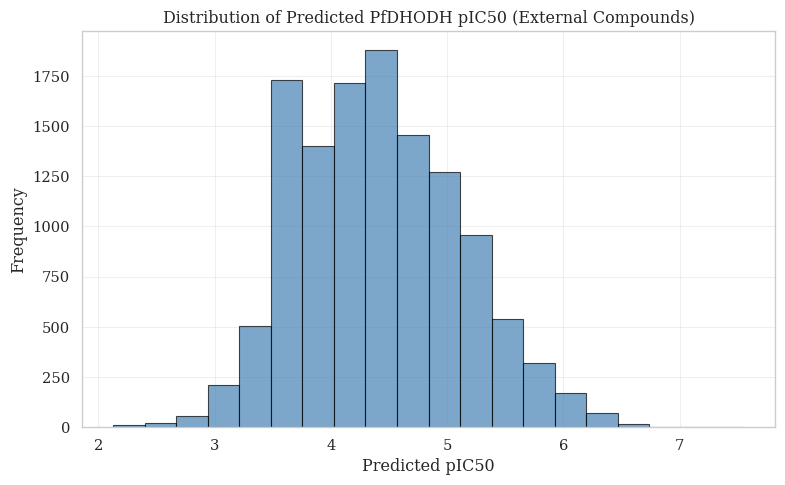

   Figure saved as external_PfDHODH_pIC50_distribution.png


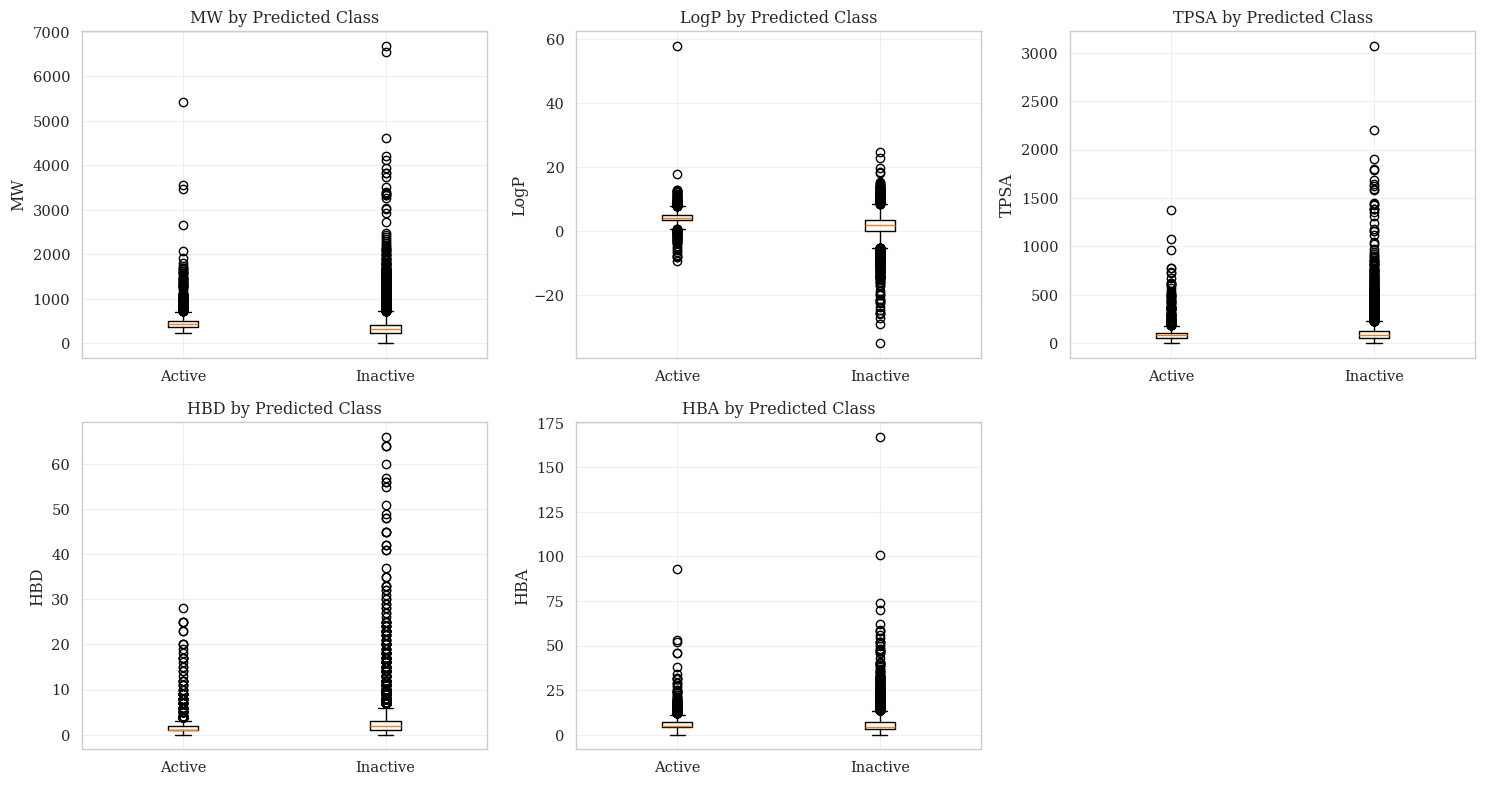

   Figure saved as external_PfDHODH_property_boxplots.png

[2] Property statistics by predicted class:

  ACTIVE (n=2599):
            MW     LogP     TPSA      HBD      HBA
count  2599.00  2599.00  2599.00  2599.00  2599.00
mean    475.53     4.13    91.11     1.71     6.09
std     225.09     2.13    77.24     2.20     4.25
min     232.31    -9.59     0.00     0.00     0.00
25%     373.01     3.21    54.04     1.00     4.00
50%     435.29     4.07    80.77     1.00     5.00
75%     508.56     4.97   106.24     2.00     7.00
max    5418.85    57.75  1372.42    28.00    93.00

  INACTIVE (n=9708):
            MW     LogP     TPSA      HBD      HBA
count  9708.00  9708.00  9708.00  9708.00  9708.00
mean    364.32     1.35   108.60     2.87     5.52
std     282.36     3.31   118.03     3.76     5.24
min       2.02   -35.16     0.00     0.00     0.00
25%     223.28    -0.19    54.82     1.00     3.00
50%     317.82     1.69    85.77     2.00     4.00
75%     420.46     3.23   124.29     3.

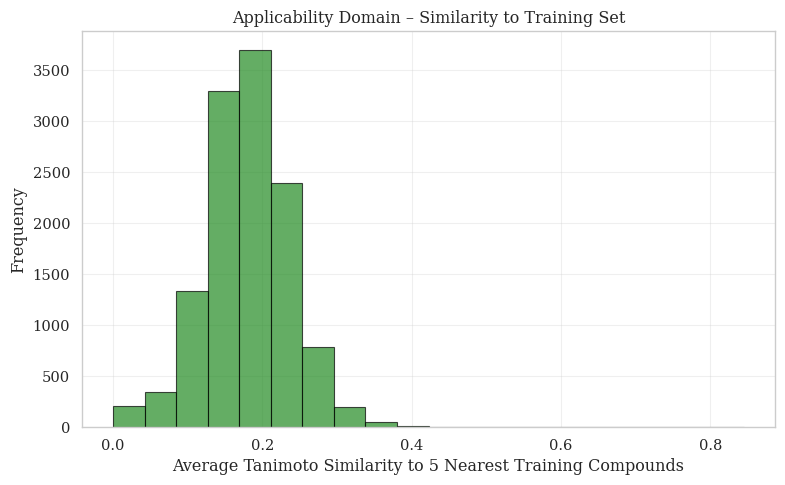

   Figure saved as external_PfDHODH_similarity_distribution.png
   Compounds with avg similarity < 0.5 : 12296

[4] t‑SNE clustering of 2599 predicted active compounds


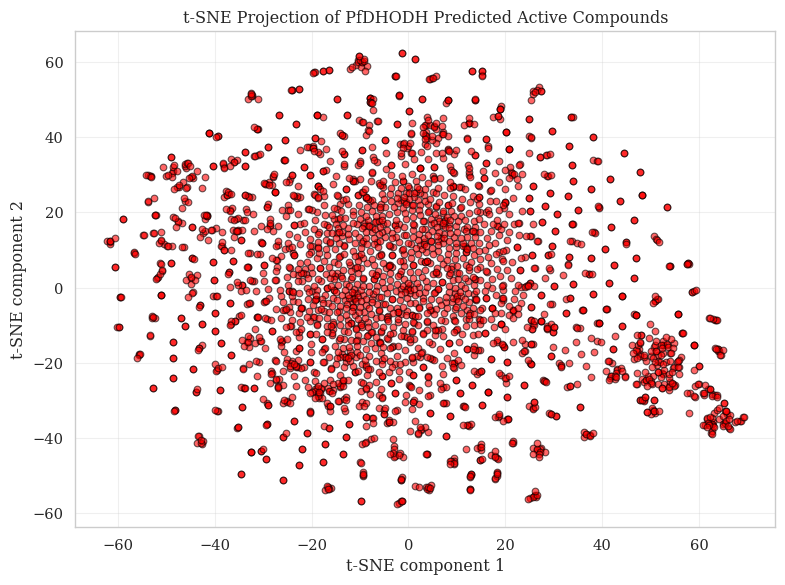

   Figure saved as external_PfDHODH_tsne_actives.png

[SAVED] Enhanced results with similarity scores: screening_results_with_eda.csv

PHASE 11 COMPLETE – EXTERNAL SCREENING EDA FINISHED


In [13]:
# =============================================================================
# PHASE 11: POST‑SCREENING EXPLORATORY ANALYSIS
# =============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

print("\n" + "="*80)
print("PHASE 11: POST‑SCREENING EXPLORATORY ANALYSIS")
print("="*80)

# -----------------------------------------------------------------------------
# Load results from Phase 10
# -----------------------------------------------------------------------------
results_file = "screening_results.csv"
if not os.path.exists(results_file):
    raise FileNotFoundError(f"{results_file} not found. Please run Phase 10 first.")

results = pd.read_csv(results_file)
print(f"\n[LOADED] {results_file} – {len(results)} compounds.")

# Load training data (for comparison)
train_file = "04_PfDHODH_final_dataset_with_descriptors.csv"
if os.path.exists(train_file):
    df_train = pd.read_csv(train_file)
    print(f"[LOADED] Training data: {df_train.shape}")
else:
    raise FileNotFoundError(f"Training file {train_file} not found. Run the full pipeline first.")

# Extract fingerprint columns (needed for applicability domain)
fp_config = pickle.load(open("PfDHODH_deployment_models/fingerprint_config.pkl", 'rb'))
fp_cols = [f'MorganFP_{i}' for i in range(fp_config['n_bits'])]

# -----------------------------------------------------------------------------
# 1. Distribution of predicted pIC50
# -----------------------------------------------------------------------------
print("\n[1] Predicted PfDHODH pIC50 distribution")
plt.figure(figsize=(8,5))
plt.hist(results['predicted_pIC50'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Predicted pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted PfDHODH pIC50 (External Compounds)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('external_PfDHODH_pIC50_distribution.png', dpi=300)
plt.show()
print("   Figure saved as external_PfDHODH_pIC50_distribution.png")

# -----------------------------------------------------------------------------
# 2. Property comparison between predicted actives and inactives
# -----------------------------------------------------------------------------
if results['predicted_class'].nunique() > 1:
    props = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, prop in enumerate(props):
        data = [results[results['predicted_class']==cls][prop].dropna() for cls in ['active','inactive']]
        axes[i].boxplot(data, labels=['Active','Inactive'])
        axes[i].set_ylabel(prop)
        axes[i].set_title(f'{prop} by Predicted Class')
        axes[i].grid(alpha=0.3)
    axes[-1].axis('off')
    plt.tight_layout()
    plt.savefig('external_PfDHODH_property_boxplots.png', dpi=300)
    plt.show()
    print("   Figure saved as external_PfDHODH_property_boxplots.png")

    print("\n[2] Property statistics by predicted class:")
    for cls in ['active','inactive']:
        subset = results[results['predicted_class']==cls]
        print(f"\n  {cls.upper()} (n={len(subset)}):")
        print(subset[props].describe().round(2).to_string())
else:
    print("\n[2] Only one class predicted – skipping comparison.")

# -----------------------------------------------------------------------------
# 3. Applicability domain – similarity to training set
# -----------------------------------------------------------------------------
print("\n[3] Applicability domain analysis")
# Ensure training set has fingerprint columns
if all(col in df_train.columns for col in fp_cols):
    train_fp = df_train[fp_cols].values
    # Get external fingerprints from X_ext? We need them. They are in results? No, but we can recompute from SMILES if needed.
    # Simpler: use the descriptor DataFrame from Phase 10? Not saved. We'll recompute from SMILES in results.
    print("   Re‑computing fingerprints for external compounds...")
    ext_fp_list = []
    for smi in results[smiles_col]:   # smiles_col is still in results because we kept all original columns
        fp = calculate_morgan_fingerprint(smi, radius=fp_config['radius'], n_bits=fp_config['n_bits'])
        ext_fp_list.append(fp)
    ext_fp = np.array(ext_fp_list)

    nn = NearestNeighbors(n_neighbors=5, metric='jaccard')
    nn.fit(train_fp)
    distances, indices = nn.kneighbors(ext_fp)
    avg_sim = 1 - distances.mean(axis=1)   # Jaccard distance → similarity
    results['avg_sim_to_train'] = avg_sim

    plt.figure(figsize=(8,5))
    plt.hist(avg_sim, bins=20, edgecolor='black', alpha=0.7, color='forestgreen')
    plt.xlabel('Average Tanimoto Similarity to 5 Nearest Training Compounds')
    plt.ylabel('Frequency')
    plt.title('Applicability Domain – Similarity to Training Set')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('external_PfDHODH_similarity_distribution.png', dpi=300)
    plt.show()
    print("   Figure saved as external_PfDHODH_similarity_distribution.png")

    low_sim = results[avg_sim < 0.5]
    print(f"   Compounds with avg similarity < 0.5 : {len(low_sim)}")
else:
    print("   Fingerprint columns not found in training data – skipping.")

# -----------------------------------------------------------------------------
# 4. t‑SNE clustering of predicted actives
# -----------------------------------------------------------------------------
n_actives = (results['predicted_class'] == 'active').sum()
if n_actives >= 10:
    print(f"\n[4] t‑SNE clustering of {n_actives} predicted active compounds")
    active_mask = results['predicted_class'] == 'active'
    # Use the already computed ext_fp (or recompute if not available)
    if 'ext_fp' not in locals():
        # recompute
        ext_fp = np.array([calculate_morgan_fingerprint(smi, radius=fp_config['radius'], n_bits=fp_config['n_bits'])
                           for smi in results[smiles_col]])
    active_fp = ext_fp[active_mask]
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, n_actives-1))
    tsne_coords = tsne.fit_transform(active_fp)

    plt.figure(figsize=(8,6))
    plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c='red', alpha=0.6, edgecolors='k')
    plt.xlabel('t‑SNE component 1')
    plt.ylabel('t‑SNE component 2')
    plt.title('t‑SNE Projection of PfDHODH Predicted Active Compounds')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('external_PfDHODH_tsne_actives.png', dpi=300)
    plt.show()
    print("   Figure saved as external_PfDHODH_tsne_actives.png")
else:
    print(f"\n[4] Not enough predicted actives for t‑SNE (n={n_actives}) – skipping.")

# -----------------------------------------------------------------------------
# 5. Save enhanced results
# -----------------------------------------------------------------------------
results.to_csv('screening_results_with_eda.csv', index=False)
print("\n[SAVED] Enhanced results with similarity scores: screening_results_with_eda.csv")

print("\n" + "="*80)
print("PHASE 11 COMPLETE – EXTERNAL SCREENING EDA FINISHED")
print("="*80)

# The END!

# **PHASE 12: Lead Candidate Selection and Drug-Likeness Profiling**
## **Identification of High-Potency Compounds with Optimal Physicochemical Profiles**

In this final phase, we consolidate the results from the external screening to identify the most promising lead candidates for *Plasmodium falciparum* DHODH inhibition. The selection process follows a multi-parametric approach to ensure the identified hits have both high biological efficacy and favorable pharmacological profiles.

### **Selection Criteria:**
1.  **Bioactivity Filter**: Retention of compounds predicted as **'active'** by the Random Forest classifier (Probability > 0.5).
2.  **Potency Ranking**: Sorting candidates by their **predicted pIC50** values (generated by the Gradient Boosting regressor) to prioritize the most potent inhibitors.
3.  **ADME/Drug-Likeness Compliance**: Strict filtering for compounds that pass **Lipinski's Rule of Five** (MW ≤ 500, LogP ≤ 5, HBD ≤ 5, HBA ≤ 10) to ensure high probability of oral bioavailability.
4.  **Property Optimization**: Evaluation of molecular weight, lipophilicity (LogP), and polarity (TPSA) to select candidates with the most balanced drug-like profiles.

---

In [14]:
# =============================================================================
# PHASE 12: LEAD CANDIDATE SELECTION
# =============================================================================

import pandas as pd
import os

print("\n" + "="*80)
print("PHASE 12: LEAD CANDIDATE SELECTION & PROFILING")
print("="*80)

# 1. Load the enhanced screening results
# Note: Using the file generated in Phase 11
results_file = 'screening_results_with_eda.csv'

if os.path.exists(results_file):
    df_leads = pd.read_csv(results_file)
    print(f"\n[INPUT] Loaded screening results: {results_file}")
else:
    # Fallback to the base screening results if the EDA file is not found
    df_leads = pd.read_csv('screening_results.csv')
    print(f"\n[INPUT] Loaded base screening results: screening_results.csv")

# 2. Apply Multi-Parametric Filters
# Filter: Predicted Active AND Lipinski Compliant
top_candidates = df_leads[
    (df_leads['predicted_class'] == 'active') & 
    (df_leads['Lipinski_pass'] == True)
].copy()

# 3. Sort by Predicted Potency (pIC50)
top_candidates = top_candidates.sort_values(by='predicted_pIC50', ascending=False)

# 4. Display the Top 10 Lead Candidates
top_10 = top_candidates.head(10)

print(f"\n[SELECTION] Identified {len(top_candidates)} compounds meeting all activity and drug-likeness criteria.")
print(f"[TOP HITS] Displaying top 10 potential PfDHODH inhibitors:")

# Define columns for a concise summary display
display_cols = ['DATABASE_ID', 'predicted_pIC50', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA']
print("\n" + top_10[display_cols].to_string(index=False))

# 5. Detail the Top Candidate (The Lead Hit)
if not top_10.empty:
    top_hit = top_10.iloc[0]
    print(f"\n" + "-"*40)
    print(f"TOP LEAD CANDIDATE PROFILE: {top_hit['DATABASE_ID']}")
    print(f"-"*40)
    print(f"  > Predicted pIC50   : {top_hit['predicted_pIC50']:.4f}")
    print(f"  > Molecular Weight : {top_hit['MW']:.2f} Da")
    print(f"  > LogP (Octanol/W) : {top_hit['LogP']:.2f}")
    print(f"  > Polar Area (TPSA): {top_hit['TPSA']:.2f} Å²")
    print(f"  > SMILES           : {top_hit['SMILES']}")
    
    # Save the selected leads to a dedicated file for further study
    top_candidates.to_csv('top_lead_candidates_PfDHODH.csv', index=False)
    print(f"\n[SAVED] Full list of prioritized leads: top_lead_candidates_PfDHODH.csv")

print("\n" + "="*80)
print("PHASE 12 COMPLETE – FINAL LEAD IDENTIFICATION FINISHED")
print("="*80)


PHASE 12: LEAD CANDIDATE SELECTION & PROFILING

[INPUT] Loaded screening results: screening_results_with_eda.csv

[SELECTION] Identified 1567 compounds meeting all activity and drug-likeness criteria.
[TOP HITS] Displaying top 10 potential PfDHODH inhibitors:

DATABASE_ID  predicted_pIC50         MW    LogP  TPSA  HBD  HBA
    DB19215         6.812099 277.292938 3.29500 56.73    1    4
    DB16898         6.743866 353.817000 3.56284 73.45    1    7
    DB07513         6.721519 329.783000 3.74480 51.47    1    4
    DB02915         6.682603 350.369000 4.97934 50.70    1    5
    DB16103         6.663264 371.258000 3.33060 55.40    1    3
    DB18282         6.648640 264.263000 3.31220 54.46    1    3
    DB03623         6.648612 272.307000 4.15560 46.01    1    3
    DB07312         6.603037 377.636000 4.58880 72.20    1    4
    DB15033         6.491369 263.275000 3.91720 41.57    1    2
    DB14914         6.491369 262.277938 3.91720 41.57    1    2

---------------------------------

Yes, **6.812099** is the highest predicted pIC50 value among the 1,567 compounds that met the specific criteria for activity and drug-likeness.

Within the prioritized list, this value represents the peak potency for a candidate that also satisfies all of the following parameters:
* **Activity**: Classified as "active" by the Random Forest model.
* **Lipinski Compliance**: Passed all "Rule of Five" requirements for oral bioavailability.
* **Physicochemical Balance**: Maintained an optimal profile across molecular weight, lipophilicity (LogP), and polar surface area (TPSA).

Because the selection logic in Phase 12 specifically sorts the filtered dataframe in descending order by `predicted_pIC50`, the compound at the top of the table (**DB19215**) is the most potent lead identified in this screening run that remains within the desired "drug-like" chemical space. Higher pIC50 values might exist in the raw screening data, but they were excluded during this phase if they failed the safety or bioavailability filters.

# **PHASE 13: Structural Visualization of Lead Candidates**
## **High-Resolution Chemical Architecture and Property Mapping**

In this phase, we generate publication-quality visual representations of the top 10 potential *Pf*DHODH inhibitors. Visualizing the chemical structures alongside their predicted biological and physicochemical properties is essential for identifying common pharmacophores and assessing the synthetic accessibility of the candidates.

### **Visualization Features:**
* **Vector Graphics**: Rendering structures in SVG format for infinite scalability and publication-grade clarity.
* **Property Legend**: Each structure is labeled with its **Database ID**, **predicted pIC50**, **Molecular Weight (MW)**, **LogP**, **TPSA**, and **Hydrogen Bond counts (HBD/HBA)**.
* **Structural Inspection**: Allows for the identification of key functional groups associated with high predicted potency.

---


PHASE 13: TOP 10 LEAD CANDIDATE STRUCTURES



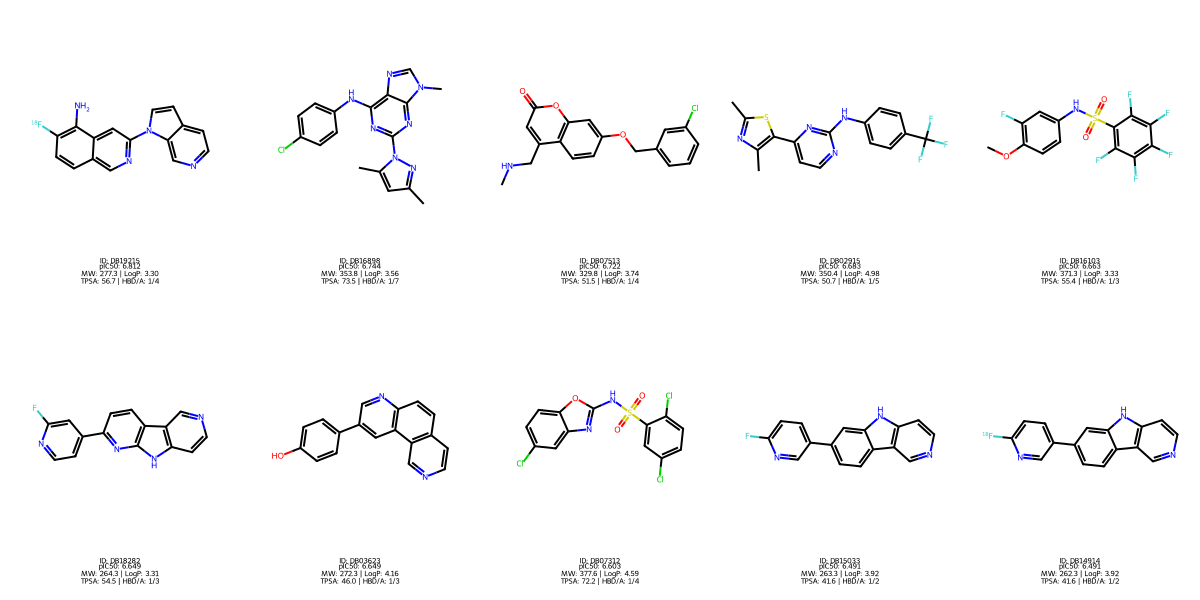


[SAVED] High-resolution structure grid saved as: top_10_leads_structures.svg



In [15]:
# =============================================================================
# PHASE 13: STRUCTURAL VISUALIZATION (PUBLICATION GRADE)
# =============================================================================

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display
import pandas as pd

# 1. Load the prioritized leads
leads_df = pd.read_csv('top_lead_candidates_PfDHODH.csv')
top_10_leads = leads_df.head(10).copy()

# 2. Prepare Molecules and Legends
mols = [Chem.MolFromSmiles(smi) for smi in top_10_leads['SMILES']]
legends = []

for idx, row in top_10_leads.iterrows():
    # Construct a multi-line legend for each molecule
    legend = (
        f"ID: {row['DATABASE_ID']}\n"
        f"pIC50: {row['predicted_pIC50']:.3f}\n"
        f"MW: {row['MW']:.1f} | LogP: {row['LogP']:.2f}\n"
        f"TPSA: {row['TPSA']:.1f} | HBD/A: {int(row['HBD'])}/{int(row['HBA'])}"
    )
    legends.append(legend)

# 3. Configure Drawing Options for Publication Quality
# We use a 5-column grid for the top 10 compounds (2 rows)
d2d = rdMolDraw2D.MolDraw2DSVG(1200, 600, 240, 300) # (TotalWidth, TotalHeight, SubImgWidth, SubImgHeight)
options = d2d.drawOptions()
options.legendFontSize = 14
options.bondLineWidth = 2
options.addAtomIndices = False
options.prepareMolsBeforeDrawing = True

# 4. Generate the Grid Image
d2d.DrawMolecules(mols, legends=legends)
d2d.FinishDrawing()

# 5. Display and Save
svg_data = d2d.GetDrawingText()
print("\n" + "="*80)
print("PHASE 13: TOP 10 LEAD CANDIDATE STRUCTURES")
print("="*80 + "\n")

display(SVG(svg_data))

# Save the SVG for publication use
with open("top_10_leads_structures.svg", "w") as f:
    f.write(svg_data)

print(f"\n[SAVED] High-resolution structure grid saved as: top_10_leads_structures.svg")
print("\n" + "="*80)